# IEEE-CIS Fraud Detection — EDA v2

**Structure:**
- **Part 1** — Transaction-level analysis (each row independent)
- **Part 2** — Customer-level analysis (grouped by `card1 + addr1`)

**Goal of Part 2:** understand whether `card1+addr1` is sufficient as UID, or whether `card1+addr1+D1` creates a better grouping key for V2 aggregations.


# IEEE-CIS Fraud Detection — EDA v2

## Goal
Explore the raw dataset to understand data quality, feature distributions, and fraud patterns
before feature engineering. Produce evidence-based decisions for the V2 preprocessing pipeline.

**Two-part structure:**
- **Part 1 — Transaction-level analysis:** target imbalance, time patterns, transaction amount,
  ProductCD, device type, email domains, card attributes, missing values, correlations, D-columns.
- **Part 2 — Customer-level analysis:** validate `card1+addr1` as the V2 grouping key (UID);
  analyse group size, fraud concentration, D1/Dx stability, amount variance, velocity, and novelty signals.

**Key decisions made in this EDA:**
- UID = `card1 + addr1` (D1 is dynamic — confirmed by anchor drift test)
- D7, D8 kept despite high NaN (|r| = 0.127 / 0.143)
- D12, D14 are drop candidates (NaN >89%, |r| < 0.03)
- `is_new_R_email` and `is_new_device` are valid novelty signals (lift 1.85× / 1.66×)
- `is_new_P_email` has no signal (lift 0.93×)
---


* All analysis functions are defined in `src/eda.py`. 
* This notebook calls them and presents CONCLUSIONS.

In [1]:
import sys
sys.path.append("./src")

from project_utils import print_project_structure
# print_project_structure()

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from eda import (
    analyze_target_imbalance,
    analyze_time_range, analyze_fraud_over_time,
    analyze_day_of_week, analyze_hour_of_day, analyze_day_of_month,
    analyze_transaction_amount,
    analyze_product_cd,
    analyze_device_type, analyze_device_product_cross,
    analyze_email_domains,
    analyze_card_attributes,
    analyze_missing_values,
    analyze_correlations,
    analyze_d_columns_basic, analyze_d_columns_nan,
    analyze_d_columns_correlations, analyze_d_columns_distributions,
    analyze_d_columns_quantile_fraud,
    analyze_uid_coverage, analyze_group_size_distribution,
    analyze_fraud_concentration, analyze_uid_addr1_value,
    analyze_d1_stability, analyze_dx_stability,
    analyze_uid_d1_comparison,
    analyze_amount_variance_by_group,
    analyze_velocity,
    analyze_novelty,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

---
# Data Loading

In [3]:
# Step 1: Load and merge
from data_loader import load_and_merge, reduce_memory, save_processed
from config import DATA_RAW

train, test = load_and_merge(DATA_RAW)

>> Loading raw CSV files...
  train_transaction: (590540, 394)
  train_identity:    (144233, 41)
  test_transaction:  (506691, 393)
  test_identity:     (141907, 41)
  In train but not in test: {'isFraud'}

>> Merging transaction + identity (left join)...
  Train after merge: (590540, 434)
  Test after merge:  (506691, 433)

  Train preview (top 7 rows):


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [4]:
train = reduce_memory(train, name="train")
test = reduce_memory(test, name="test")


>> Reducing memory for train...
   Shape: (590540, 434)
   Memory: 2514 MB → 1603 MB (↓ 36.2%)
   Dtypes: {dtype('float32'): np.int64(399), dtype('O'): np.int64(31), dtype('int32'): np.int64(2), dtype('int8'): np.int64(1), dtype('int16'): np.int64(1)}

>> Reducing memory for test...
   Shape: (506691, 433)
   Memory: 2164 MB → 1386 MB (↓ 35.9%)
   Dtypes: {dtype('float32'): np.int64(399), dtype('O'): np.int64(31), dtype('int32'): np.int64(2), dtype('int16'): np.int64(1)}


---
# PART 1 — Transaction-Level Analysis
*Each transaction is analyzed independently. No grouping by user.*


## 1.1 Target Imbalance

Target distribution (absolute):
isFraud
0    569877
1     20663
Name: count, dtype: int64

Target distribution (%):
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64


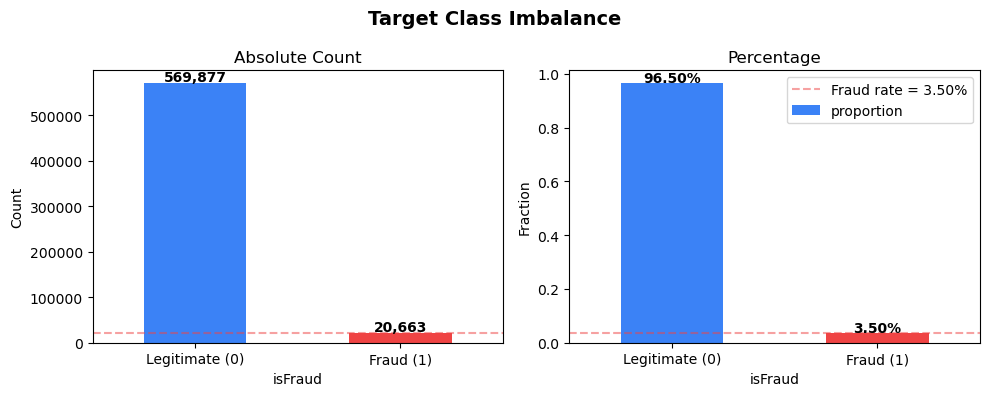

In [5]:
analyze_target_imbalance(train)


---
**CONCLUSIONS:** 
* 569,877 legitimate (96.5%) vs 20,663 fraud (3.5%). 
* **Severe class imbalance** → PR AUC is the primary metric.
---

## 1.2 Time Patterns

TransactionDT range:
  Train: 86,400 — 15,811,131
  Test:  18,403,224 — 34,214,345

Approximate days:
  Train: day 1 — day 183
  Test:  day 213 — day 396


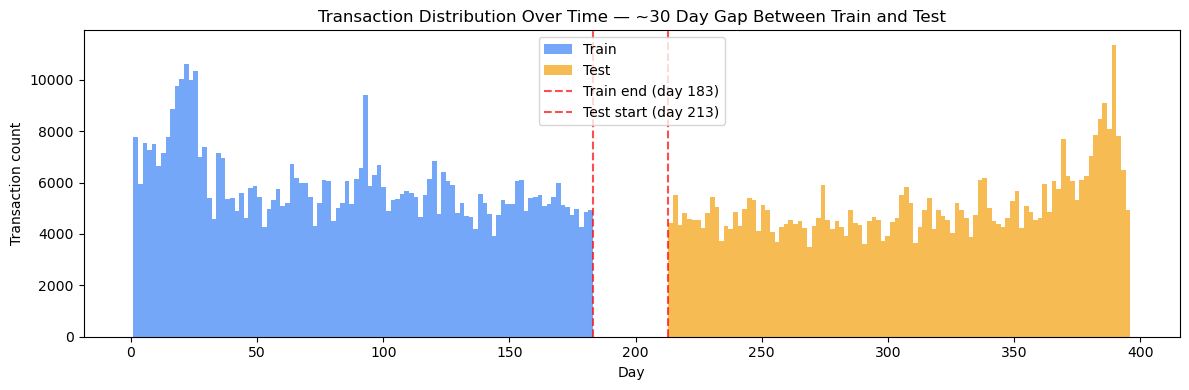

In [6]:
analyze_time_range(train, test)

---
**CONCLUSIONS:** 
* Train days 1–183
*  Test days 213–396
* There is ~30-day gap. 
* **Time-based split is mandatory — random split causes data leakage.**
---

In [7]:
# === Add time features (discovered during EDA) ===
from feature_init_utils import add_time_features

train = add_time_features(train)
test  = add_time_features(test)

>> Adding time features from TransactionDT...
   Shape before: (590540, 434)
   Added: tx_day, tx_dow, tx_hour, tx_dom
   Shape after: (590540, 438)
>> Adding time features from TransactionDT...
   Shape before: (506691, 433)
   Added: tx_day, tx_dow, tx_hour, tx_dom
   Shape after: (506691, 437)


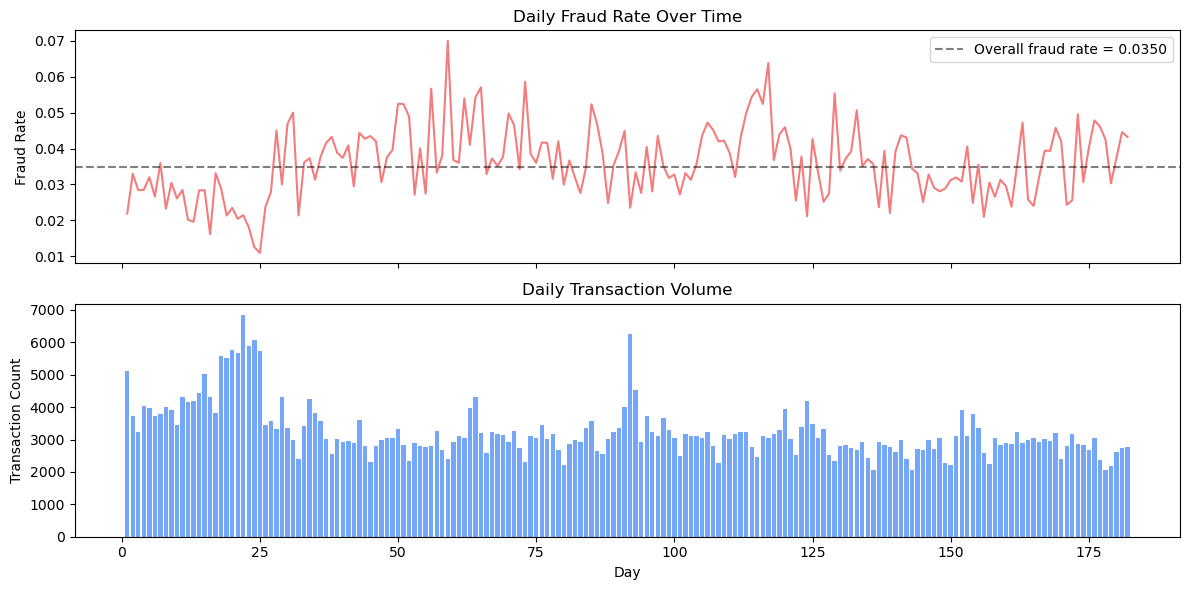

In [8]:
analyze_fraud_over_time(train)

---
**CONCLUSIONS:** 
* Daily fraud rate 1–7% (noise), no structural drift over 6 months. 
* **Single time-based 80/20 split is valid.**
---

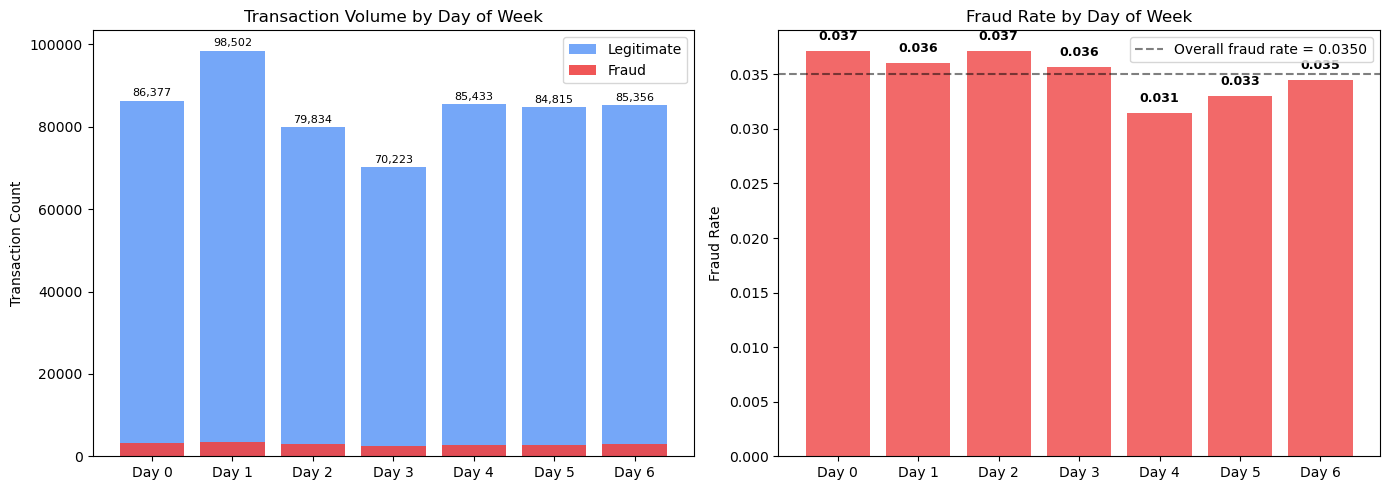

In [9]:
analyze_day_of_week(train)

---
**CONCLUSIONS:** 
* Fraud uniform across weekdays (3.1–3.7%). 
* Day of week is a weak standalone predictor.
---

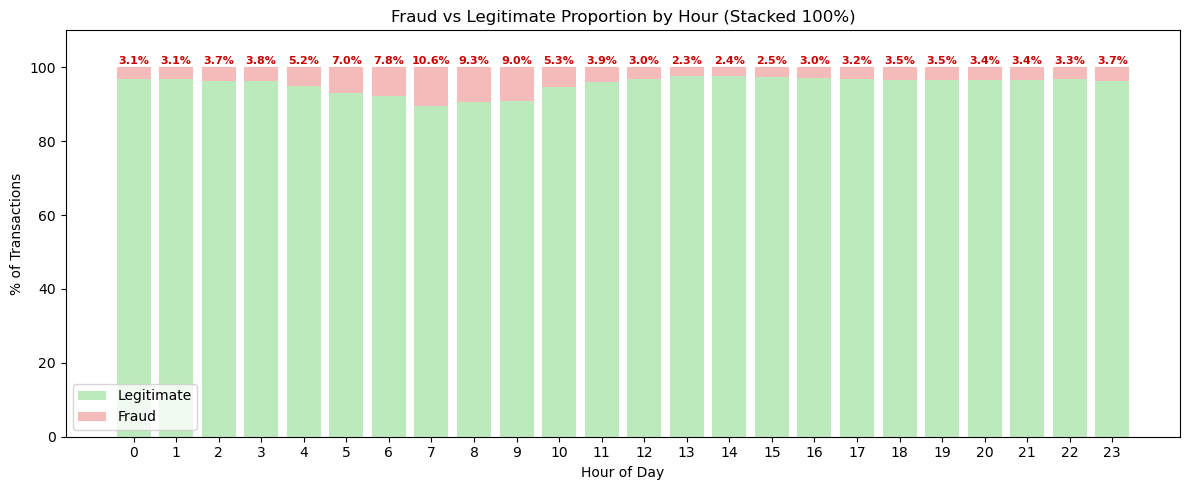

In [10]:
analyze_hour_of_day(train)

---
**CONCLUSIONS:** 
* Fraud peaks hours 5–9 (~10.6% = 3× average). 
* **Fraudsters operate in off-hours when legitimate users are inactive.**
---

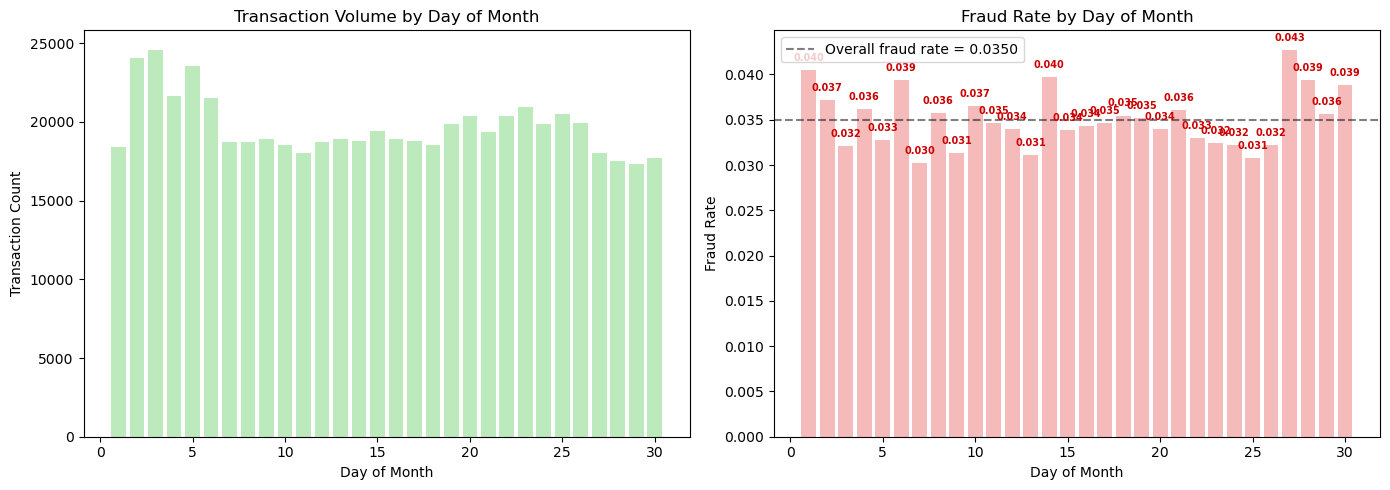

In [11]:
analyze_day_of_month(train)

---
**CONCLUSIONS:** 
* Fraud rate 3.0–4.3% by day of month. 
* No strong monthly cycle.
---

## 1.3 Transaction Amount

TransactionAmt — Fraud vs Legitimate:

  Legitimate:
    Count:     569,877
    Mean:   $    134.51
    Median: $     68.50
    Min:    $      0.25
    Max:    $ 31,937.39

  Fraud:
    Count:      20,663
    Mean:   $    149.24
    Median: $     75.00
    Min:    $      0.29
    Max:    $  5,191.00


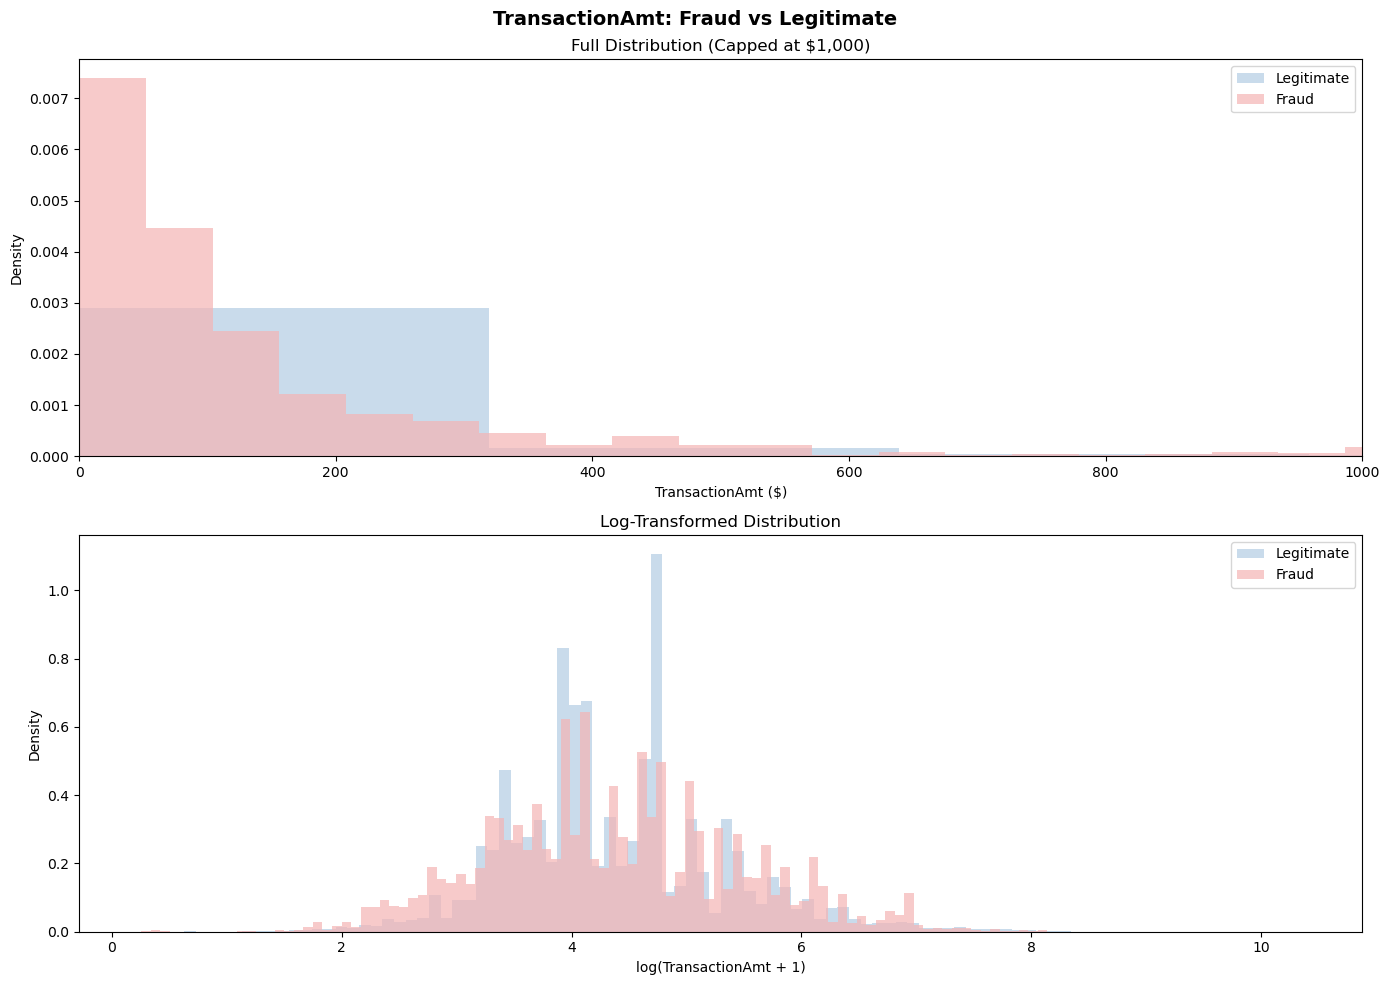

In [12]:
analyze_transaction_amount(train)

---
**CONCLUSIONS — Transaction Amount**

- **Fraud mean $149  vs Legitimate mean $135** — fraud transactions are slightly larger on average.
- **Fraud median $75 vs Legitimate median $69** — medians are close; the mean gap is driven by a long tail of large fraudulent transactions.
- **Max fraud $5,191 vs Legitimate $31,937** — the highest legitimate transactions far exceed fraud; very large amounts are not a fraud signal.
- **Distributions overlap heavily** — amount alone cannot separate fraud from legitimate.
---
- **Signal emerges in combination with user history:** 
* How does *this* transaction compare to the card's typical amount? 
* → V1 features `tx_amt_mean`, `tx_amt_ratio`, `delta_amt` capture exactly this.
---


## 1.4 ProductCD

ProductCD breakdown:
  C — Transactions:   68,519 ( 11.6%)   Fraud rate: 11.69%
  H — Transactions:   33,024 (  5.6%)   Fraud rate: 4.77%
  R — Transactions:   37,699 (  6.4%)   Fraud rate: 3.78%
  S — Transactions:   11,628 (  2.0%)   Fraud rate: 5.90%
  W — Transactions:  439,670 ( 74.5%)   Fraud rate: 2.04%


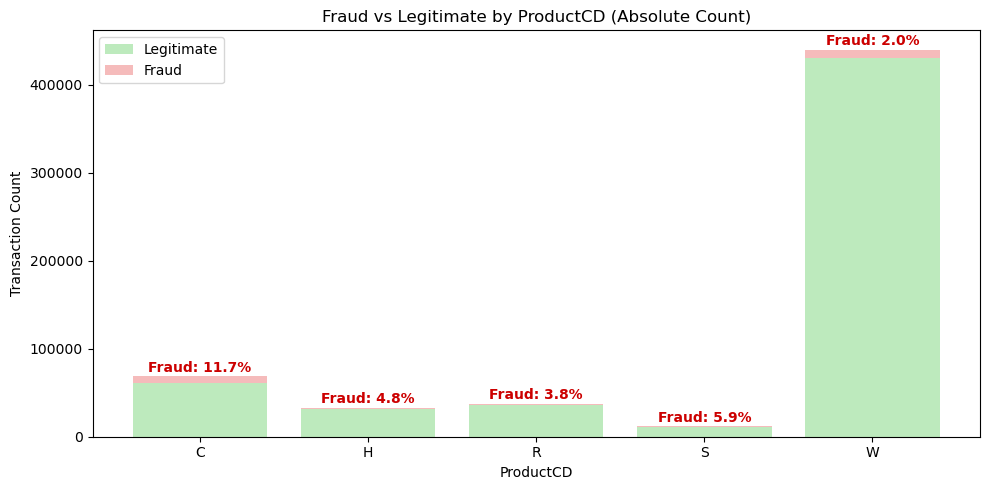

In [13]:
analyze_product_cd(train)

---
**CONCLUSIONS — 1.4 ProductCD**

- **'C' has the highest fraud rate: 11.69%** — 3.3× the dataset average (3.5%).
- **'W' dominates volume (74.5%)** with the lowest fraud rate (2.04%) — most transactions are low-risk.
- **'S' (5.90%), 'H' (4.77%)** — elevated above average.
- **'R' (3.78%)** — close to average, weakest discriminative value.
---
- **ProductCD is a strong categorical feature**  (included in V1 pipeline).
---


## 1.5 Device Type

DeviceType Analysis:
  desktop    — Transactions:   85,165   Fraud rate: 0.0652 (6.52%)
  mobile     — Transactions:   55,645   Fraud rate: 0.1017 (10.17%)

  No device info — Transactions:  449,730   (76.2% of all data)


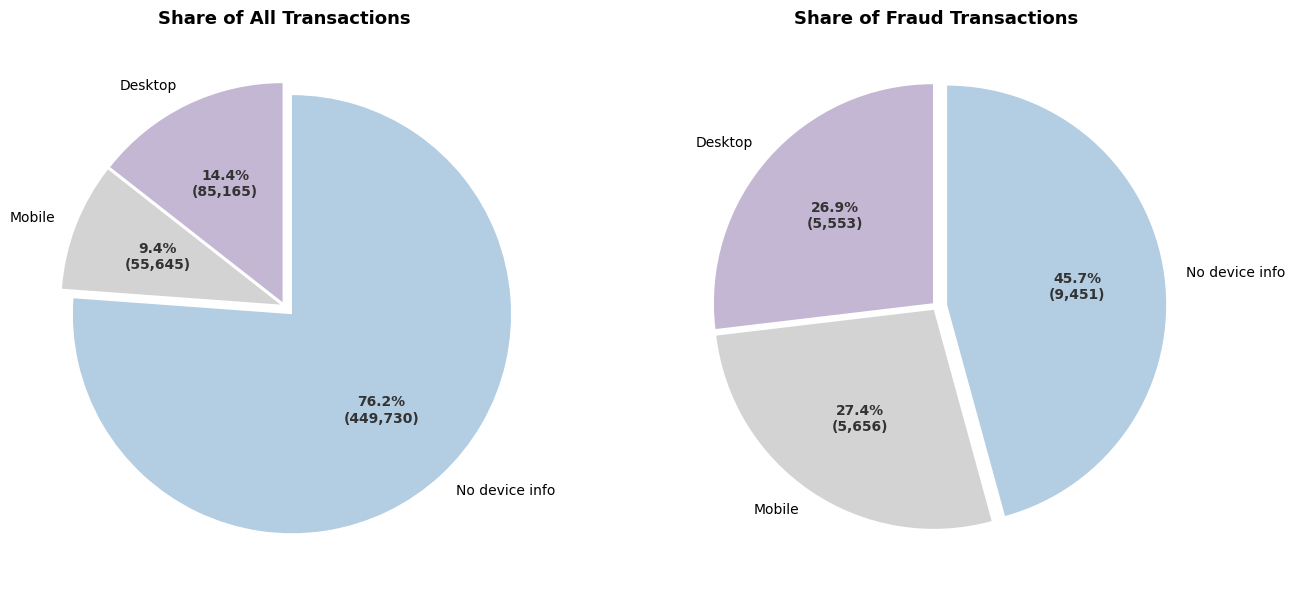

In [14]:
analyze_device_type(train)

In [15]:
# === Add device features (discovered during EDA) ===
from feature_init_utils import add_device_features

train = add_device_features(train)
test = add_device_features(test)

>> Adding device features...
   Shape before: (590540, 438)
   Added: DeviceType_filled
   Shape after: (590540, 439)
>> Adding device features...
   Shape before: (506691, 437)
   Added: DeviceType_filled
   Shape after: (506691, 438)


DeviceType distribution within each ProductCD (%):
DeviceType_filled  No device info  desktop  mobile
ProductCD                                         
C                            11.0     46.5    42.6
H                             2.8     57.6    39.6
R                             3.4     66.6    30.0
S                             3.1     79.1    17.8
W                           100.0      0.0     0.0


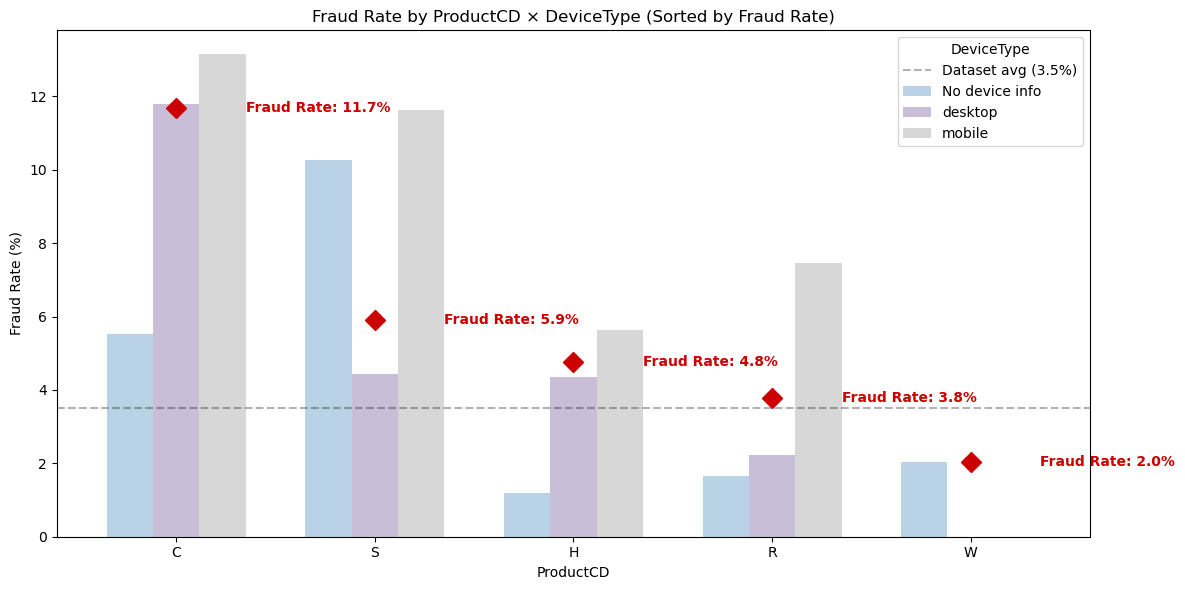

In [16]:
analyze_device_product_cross(train)

---
**CONCLUSIONS — Device Type**

- **Mobile has the highest fraud rate: 10.17%** — nearly 3× average (3.5%). Desktop is 6.52%.
- **76.2% of transactions have no device info** — these are likely API/automated transactions with a lower fraud rate than device-identified ones.
- ProductCD 'W' is 100% "no device info" — all web transactions arrive without device fingerprint.
---
- **Mobile fraud signal is consistent across all ProductCD categories** 
- (C, H, R, S) — device type is a standalone signal, not a ProductCD artifact.
---


## 1.6 Email Domains

  P_emaildomain: unique:   59   NaN: 16.0%
  R_emaildomain: unique:   60   NaN: 76.8%

P_emaildomain — Top 10 by transaction count:
  gmail.com                 — Tx:  228,355 ( 38.7%)   Fraud rate: 4.35%
  yahoo.com                 — Tx:  100,934 ( 17.1%)   Fraud rate: 2.28%
  hotmail.com               — Tx:   45,250 (  7.7%)   Fraud rate: 5.30%
  anonymous.com             — Tx:   36,998 (  6.3%)   Fraud rate: 2.32%
  aol.com                   — Tx:   28,289 (  4.8%)   Fraud rate: 2.18%
  comcast.net               — Tx:    7,888 (  1.3%)   Fraud rate: 3.12%
  icloud.com                — Tx:    6,267 (  1.1%)   Fraud rate: 3.14%
  outlook.com               — Tx:    5,096 (  0.9%)   Fraud rate: 9.46%
  msn.com                   — Tx:    4,092 (  0.7%)   Fraud rate: 2.20%
  att.net                   — Tx:    4,033 (  0.7%)   Fraud rate: 0.74%

R_emaildomain — Top 10 by transaction count:
  gmail.com                 — Tx:   57,147 (  9.7%)   Fraud rate: 11.92%
  hotmail.com               —

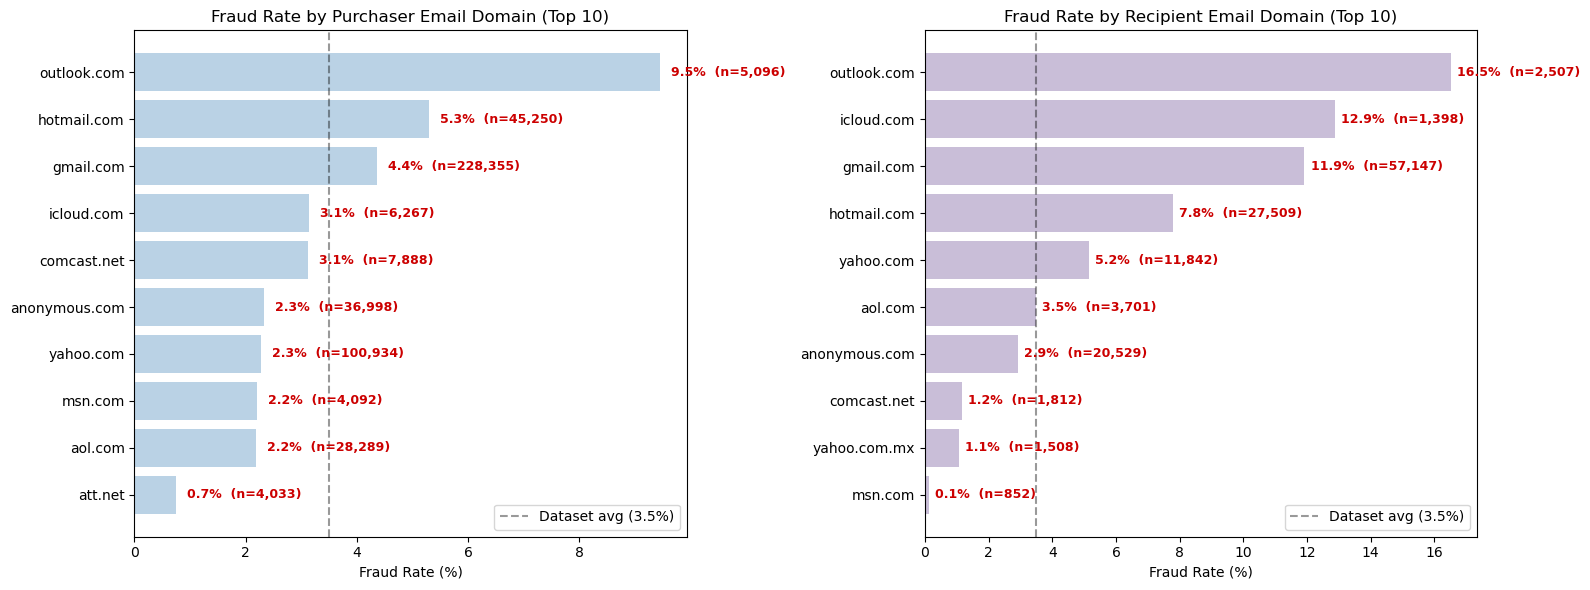

In [17]:
analyze_email_domains(train)

---
**CONCLUSIONS — Email Domains**

- **P_emaildomain (purchaser):** outlook.com has the highest fraud rate among top domains (9.46% — 2.7× average). hotmail.com also elevated (5.30%). gmail.com is the largest domain (38.7%) but close to average (4.35%).

- **R_emaildomain (recipient) shows dramatically higher fraud rates:** outlook.com **16.51%**, icloud.com **12.88%**, gmail.com **11.92%**, hotmail.com **7.78%**. Fraudsters control the recipient address — R_emaildomain is a stronger signal than P_emaildomain.

- **R_emaildomain is 76.8% NaN** — the recipient field is absent in most legitimate transactions. NaN itself is a weak negative fraud signal.

- **P≠R email domain mismatch** → V1 feature `is_same_email_domain` (rank 16 in V1 importance).

- **is_new_R_email lift 1.85×, is_new_P_email lift 0.93×** (EDA 2.10) — R_emaildomain novelty is a signal, P_emaildomain novelty is not.
---


## 1.7 Card Attributes

  card1: int16       unique: 13,553   NaN: 0.0%
  card2: float32     unique:    500   NaN: 1.5%
  card3: float32     unique:    114   NaN: 0.3%
  card4: object      unique:      4   NaN: 0.3%
  card5: float32     unique:    119   NaN: 0.7%
  card6: object      unique:      4   NaN: 0.3%



,TransactionID,card1,card2,card3,card4,card5,card6,isFraud
0,2987000,13926,NaN,150.0,discover,142.0,credit,0
1,2987001,2755,404.0,150.0,mastercard,102.0,credit,0
2,2987002,4663,490.0,150.0,visa,166.0,debit,0
3,2987003,18132,567.0,150.0,mastercard,117.0,debit,0
4,2987004,4497,514.0,150.0,mastercard,102.0,credit,0
5,2987005,5937,555.0,150.0,visa,226.0,debit,0
6,2987006,12308,360.0,150.0,visa,166.0,debit,0
7,2987007,12695,490.0,150.0,visa,226.0,debit,0
8,2987008,2803,100.0,150.0,visa,226.0,debit,0
9,2987009,17399,111.0,150.0,mastercard,224.0,debit,0



card4 breakdown:
  american express — Tx:    8,328 (  1.4%)   Fraud rate: 2.87%
  discover        — Tx:    6,651 (  1.1%)   Fraud rate: 7.73%
  mastercard      — Tx:  189,217 ( 32.0%)   Fraud rate: 3.43%
  visa            — Tx:  384,767 ( 65.2%)   Fraud rate: 3.48%

card6 breakdown:
  charge card     — Tx:       15 (  0.0%)   Fraud rate: 0.00%
  credit          — Tx:  148,986 ( 25.2%)   Fraud rate: 6.68%
  debit           — Tx:  439,938 ( 74.5%)   Fraud rate: 2.43%
  debit or credit — Tx:       30 (  0.0%)   Fraud rate: 0.00%


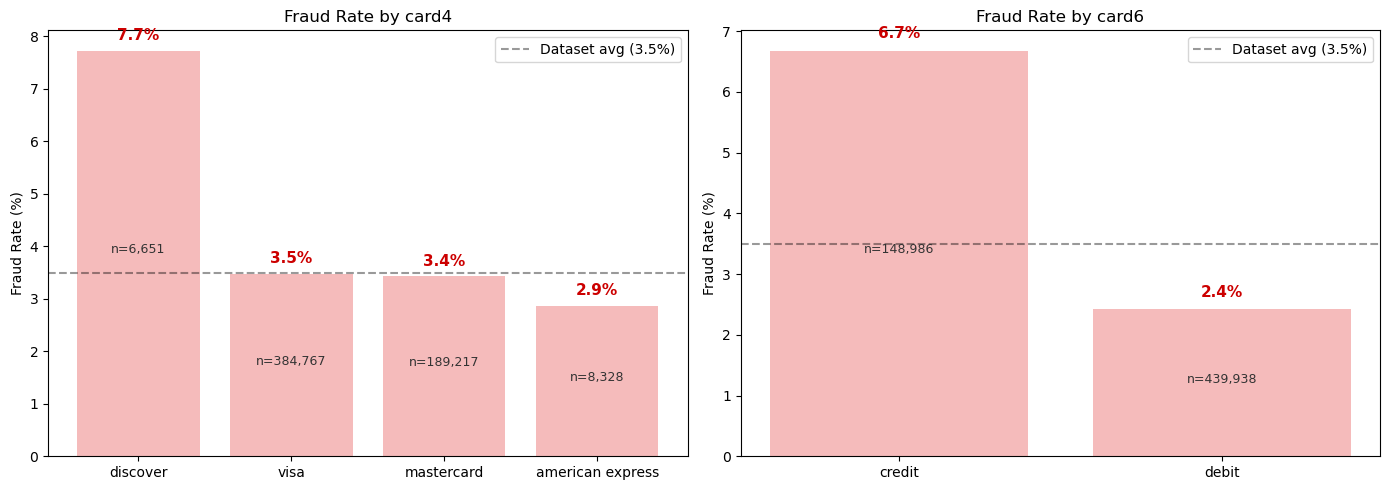

In [18]:
analyze_card_attributes(train)

---
**CONCLUSIONS:** 
* card1 — 13,553 unique values, 0% NaN, strongest card identifier. 
* card2 (500 unique, likely expiry), 1.5% NaN. 
* card4/card6 are categorical.
---
* Discover network highest fraud rate (7.7% = 2× average). 
* **Credit cards higher fraud rate than debit.**
* These categorical card features add signal beyond raw card numbers.
---

## 1.8 Missing Values

Missing Values Summary:
  Columns with 0% NaN:     25
  Columns with 0-25% NaN:  162
  Columns with 25-50% NaN: 38
  Columns with 50-75% NaN: 6
  Columns with 75%+ NaN:   208

  Total columns: 439


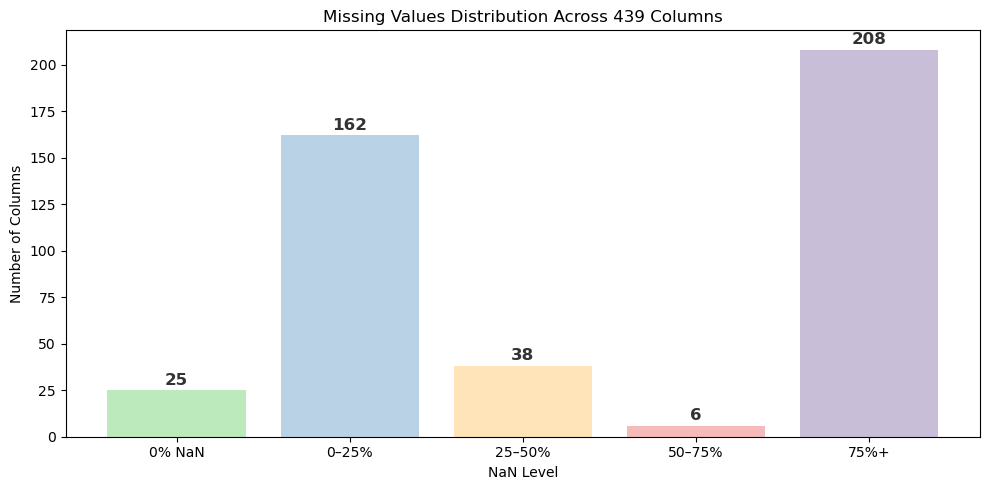


  0% NaN: 25 columns

  Other columns (25):


,NaN %,dtype,unique,top 5 vals
column,,,,
C9,0.0%,float32,205,"[1.0, 0.0, 2.0, 3.0, 4.0]"
C14,0.0%,float32,1108,"[1.0, 2.0, 3.0, 0.0, 4.0]"
card1,0.0%,int16,13553,"[7919, 9500, 15885, 17188, 15066]"
C4,0.0%,float32,1260,"[0.0, 1.0, 2.0, 3.0, 4.0]"
C5,0.0%,float32,319,"[0.0, 1.0, 2.0, 3.0, 4.0]"
ProductCD,0.0%,object,5,"['W', 'C', 'R', 'H', 'S']"
C8,0.0%,float32,1253,"[0.0, 1.0, 2.0, 3.0, 4.0]"
C7,0.0%,float32,1103,"[0.0, 1.0, 2.0, 3.0, 4.0]"
C6,0.0%,float32,1328,"[1.0, 2.0, 0.0, 3.0, 4.0]"



  0–25% NaN: 162 columns

  V-columns (151): V12–V321

  Other columns (11):


,NaN %,dtype,unique,top 5 vals
column,,,,
P_emaildomain,16.0%,object,59,"['gmail.com', 'yahoo.com', 'hotmail.com', 'ano..."
D15,15.1%,float32,859,"[0.0, 1.0, 2.0, 3.0, 7.0]"
D10,12.9%,float32,818,"[0.0, 1.0, 2.0, 3.0, 7.0]"
addr1,11.1%,float32,332,"[299.0, 325.0, 204.0, 264.0, 330.0]"
addr2,11.1%,float32,74,"[87.0, 60.0, 96.0, 32.0, 65.0]"
card2,1.5%,float32,500,"[321.0, 111.0, 555.0, 490.0, 583.0]"
card5,0.7%,float32,119,"[226.0, 224.0, 166.0, 102.0, 117.0]"
card4,0.3%,object,4,"['visa', 'mastercard', 'american express', 'di..."
card6,0.3%,object,4,"['debit', 'credit', 'debit or credit', 'charge..."



  25–50% NaN: 38 columns

  V-columns (29): V1–V52

  Other columns (9):


,NaN %,dtype,unique,top 5 vals
column,,,,
M4,47.7%,object,3,"['M0', 'M2', 'M1']"
D2,47.5%,float32,641,"[0.0, 1.0, 2.0, 3.0, 4.0]"
D11,47.3%,float32,676,"[0.0, 1.0, 2.0, 3.0, 7.0]"
M3,45.9%,object,2,"['T', 'F']"
M1,45.9%,object,2,"['T', 'F']"
M2,45.9%,object,2,"['T', 'F']"
D3,44.5%,float32,649,"[0.0, 1.0, 2.0, 7.0, 3.0]"
M6,28.7%,object,2,"['F', 'T']"
D4,28.6%,float32,808,"[0.0, 1.0, 2.0, 3.0, 4.0]"



  50–75% NaN: 6 columns

  Other columns (6):


,NaN %,dtype,unique,top 5 vals
column,,,,
dist1,59.7%,float32,2651,"[0.0, 1.0, 2.0, 4.0, 3.0]"
M5,59.3%,object,2,"['F', 'T']"
M7,58.6%,object,2,"['F', 'T']"
M8,58.6%,object,2,"['F', 'T']"
M9,58.6%,object,2,"['T', 'F']"
D5,52.5%,float32,688,"[0.0, 1.0, 2.0, 7.0, 3.0]"



  75%+ NaN: 208 columns

  V-columns (159): V138–V339
  Identity columns (38): id_01, id_02, id_03, id_04, id_05, id_06, id_07, id_08, id_09, id_10, id_11, id_12, id_13, id_14, id_15, id_16, id_17, id_18, id_19, id_20, id_21, id_22, id_23, id_24, id_25, id_26, id_27, id_28, id_29, id_30, id_31, id_32, id_33, id_34, id_35, id_36, id_37, id_38

  Other columns (11):


,NaN %,dtype,unique,top 5 vals
column,,,,
dist2,93.6%,float32,1751,"[7.0, 0.0, 1.0, 9.0, 4.0]"
D7,93.4%,float32,597,"[0.0, 1.0, 2.0, 3.0, 7.0]"
D13,89.5%,float32,577,"[0.0, 1.0, 26.0, 2.0, 3.0]"
D14,89.5%,float32,802,"[0.0, 1.0, 256.0, 2.0, 3.0]"
D12,89.0%,float32,635,"[0.0, 1.0, 2.0, 3.0, 4.0]"
D6,87.6%,float32,829,"[0.0, 1.0, 256.0, 2.0, 3.0]"
D9,87.3%,float32,24,"[0.7916659712791443, 0.8333330154418945, 0.75,..."
D8,87.3%,float32,12353,"[0.7916659712791443, 0.8333330154418945, 0.875..."
DeviceInfo,79.9%,object,1786,"['Windows', 'iOS Device', 'MacOS', 'Trident/7...."


In [19]:
analyze_missing_values(train)

---
**CONCLUSIONS:** 
* 25 columns (6%) have 0% NaN. 
* V and id columns dominate high-NaN groups. 
* Fill strategy: -1 for LightGBM/XGBoost (handled natively as a split point).
---

## 1.9 Correlations with isFraud

Top 20 features most correlated with isFraud (absolute value):
  V257                       |r| = 0.3831
  V246                       |r| = 0.3669
  V244                       |r| = 0.3641
  V242                       |r| = 0.3606
  V201                       |r| = 0.3280
  V200                       |r| = 0.3188
  V189                       |r| = 0.3082
  V188                       |r| = 0.3036
  V258                       |r| = 0.2972
  V45                        |r| = 0.2818
  V158                       |r| = 0.2781
  V156                       |r| = 0.2760
  V149                       |r| = 0.2733
  V228                       |r| = 0.2689
  V44                        |r| = 0.2604
  V86                        |r| = 0.2518
  V87                        |r| = 0.2517
  V170                       |r| = 0.2498
  V147                       |r| = 0.2429
  V52                        |r| = 0.2395

Bottom 5 (least correlated):
  V299                       |r| = 0.0003
  V135                   

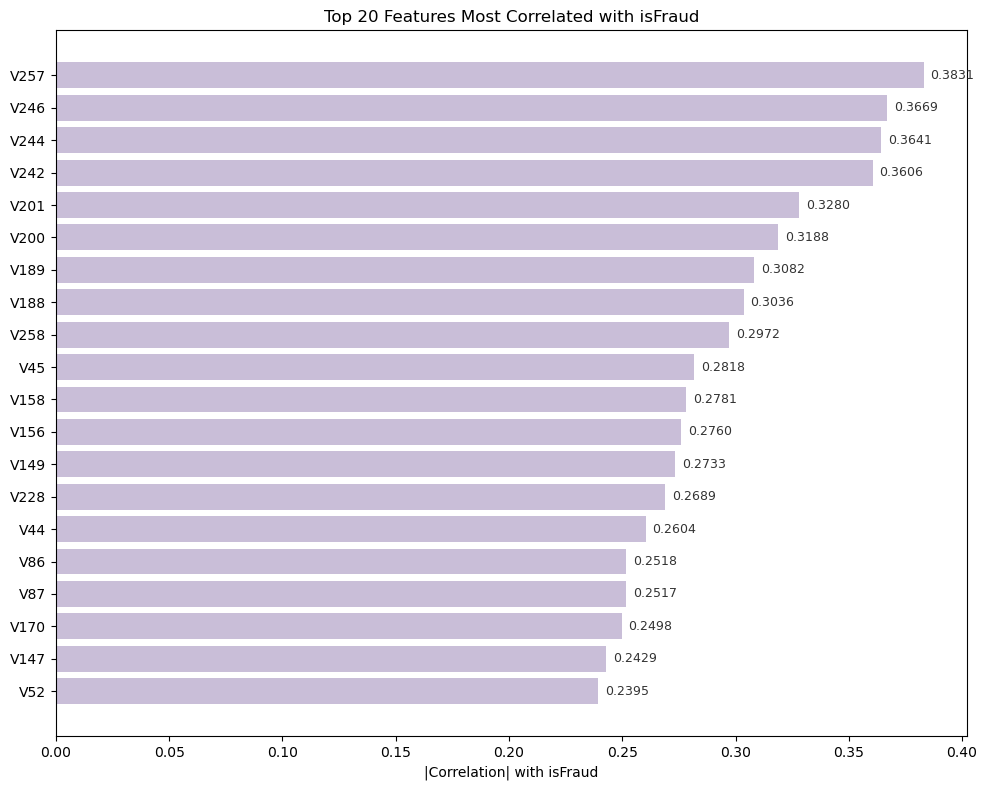

In [20]:
correlations = analyze_correlations(train)

---
**CONCLUSIONS:** 
* All top-20 are V-columns. 
* Pearson is a lower bound for non-linear signal — LightGBM feature importance reveals stronger relationships for card1, TransactionAmt, D-columns.
---

---
## 1.10 D-Columns — Transaction-Level Analysis
*Raw distributions and fraud signal per transaction. UID stability tested in Part 2.*


### 1.10.1 Basic Stats

In [21]:
d_cols_present = analyze_d_columns_basic(train)

Col         dtype    NaN %    neg %         min         max        mean      median
-------------------------------------------------------------------------------------
  D1       float32     0.2%     0.0%         0.0       640.0        94.3         3.0
  D2       float32    47.5%     0.0%         0.0       640.0       169.6        97.0
  D3       float32    44.5%     0.0%         0.0       819.0        28.3         8.0
  D4       float32    28.6%     0.0%      -122.0       869.0       140.0        26.0
  D5       float32    52.5%     0.0%         0.0       819.0        42.3        10.0
  D6       float32    87.6%     0.0%       -83.0       873.0        69.8         0.0
  D7       float32    93.4%     0.0%         0.0       843.0        41.6         0.0
  D8       float32    87.3%     0.0%         0.0      1707.8       146.1        37.9
  D9       float32    87.3%     0.0%         0.0         1.0         0.6         0.7
  D10      float32    12.9%     0.0%         0.0       876.0     

---
**CONCLUSIONS — 1.10.1 D-Column Basic Stats**

- **D9 range 0–1** → NOT days (likely time-of-day fraction, e.g. 0.7 = 70% through the day). Excluded from D-column analysis.
- **D1 has 0.2% NaN** — the most complete D-column, covering 99.8% of transactions.
- **neg% shows 0.0% for all D-columns** — this reflects float32 precision after `reduce_memory`. However, minimum values confirm real negatives exist: D4 min=−122, D6 min=−83, D11 min=−53, D12 min=−83, D14 min=−193, D15 min=−83. These are genuine negative timedelta values. **Do NOT clip negatives** — they carry distinct fraud/legit signal (confirmed in 1.10.4).
- **D8 max=1,707.8** — unusually large range, suggesting a different time reference or unit than other D-columns.
---


### 1.10.2 Missing Values

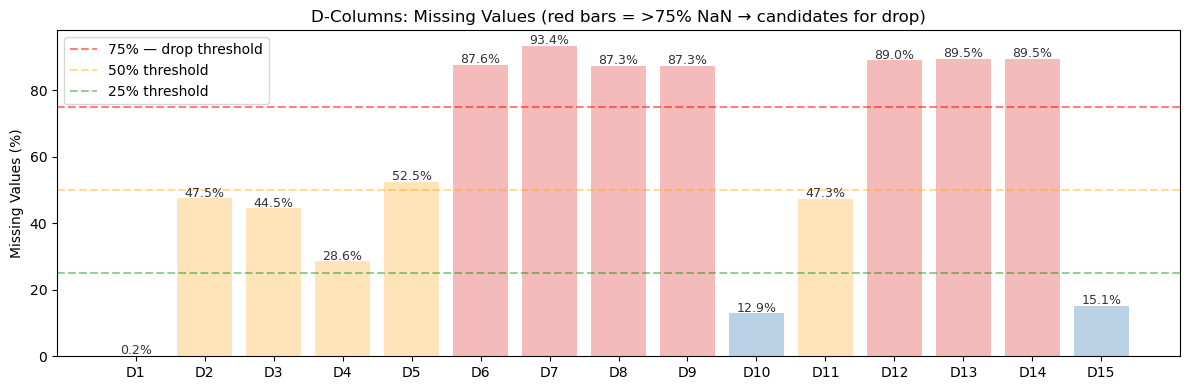

Drop candidates (>75% NaN): ['D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14']
Keep candidates (≤75% NaN): ['D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']


In [22]:
analyze_d_columns_nan(train, d_cols_present)

**Drop rule (1.10.2):** NaN% alone is insufficient — must combine with correlation:
- **D7** (NaN 93.4%, |r|=0.127), **D8** (NaN 87.3%, |r|=0.143) → **KEEP** — high signal despite high NaN
- **D14** (NaN 89.5%, |r|=0.009), **D12** (NaN 89.0%, |r|=0.029) → **DROP** — high NaN AND negligible signal
- **D13** (NaN 89.5%, |r|=0.059), **D6** (NaN 87.6%, |r|=0.057), **D9** (NaN 87.3%, |r|=0.044) → **borderline** — see full criteria in section 1.11
- Others (NaN ≤75%): keep with fill=-1


### 1.10.3 Correlations with isFraud

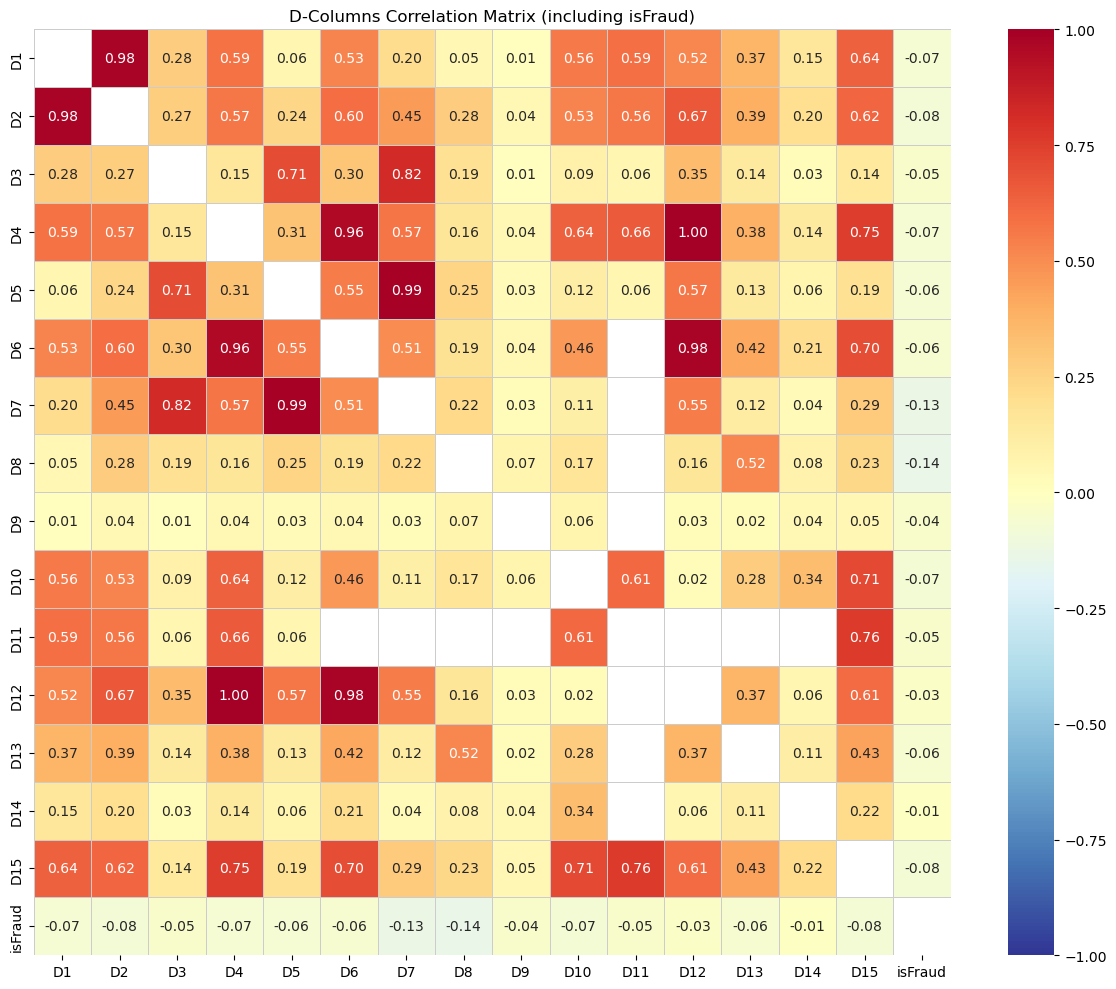


D-column correlations with isFraud (sorted by |r|):
  D8: |r| = 0.1426   NaN: 87%
  D7: |r| = 0.1272   NaN: 93%
  D2: |r| = 0.0836   NaN: 48%
  D15: |r| = 0.0775   NaN: 15%
  D10: |r| = 0.0720   NaN: 13%
  D4: |r| = 0.0672   NaN: 29%
  D1: |r| = 0.0672   NaN: 0%
  D5: |r| = 0.0646   NaN: 52%
  D13: |r| = 0.0594   NaN: 90%
  D6: |r| = 0.0572   NaN: 88%
  D3: |r| = 0.0463   NaN: 45%
  D11: |r| = 0.0451   NaN: 47%
  D9: |r| = 0.0443   NaN: 87%
  D12: |r| = 0.0289   NaN: 89%
  D14: |r| = 0.0087   NaN: 89%


In [23]:
analyze_d_columns_correlations(train, d_cols_present)

---
**CONCLUSIONS:** 
* Best signal+coverage: 
    * D15 (|r|=0.078, NaN 15%), 
    * D10 (|r|=0.072, NaN 13%), 
    * D4 (|r|=0.067, NaN 29%), 
    * D1 (|r|=0.067, NaN 0%). 
* V2 normalization priority: these 4 columns. 
* Pearson understates real signal — V1 importance confirms D15(rank 20), D10(24), D4(29), D1(30).
---

### 1.10.4 Distributions — Fraud vs Legitimate

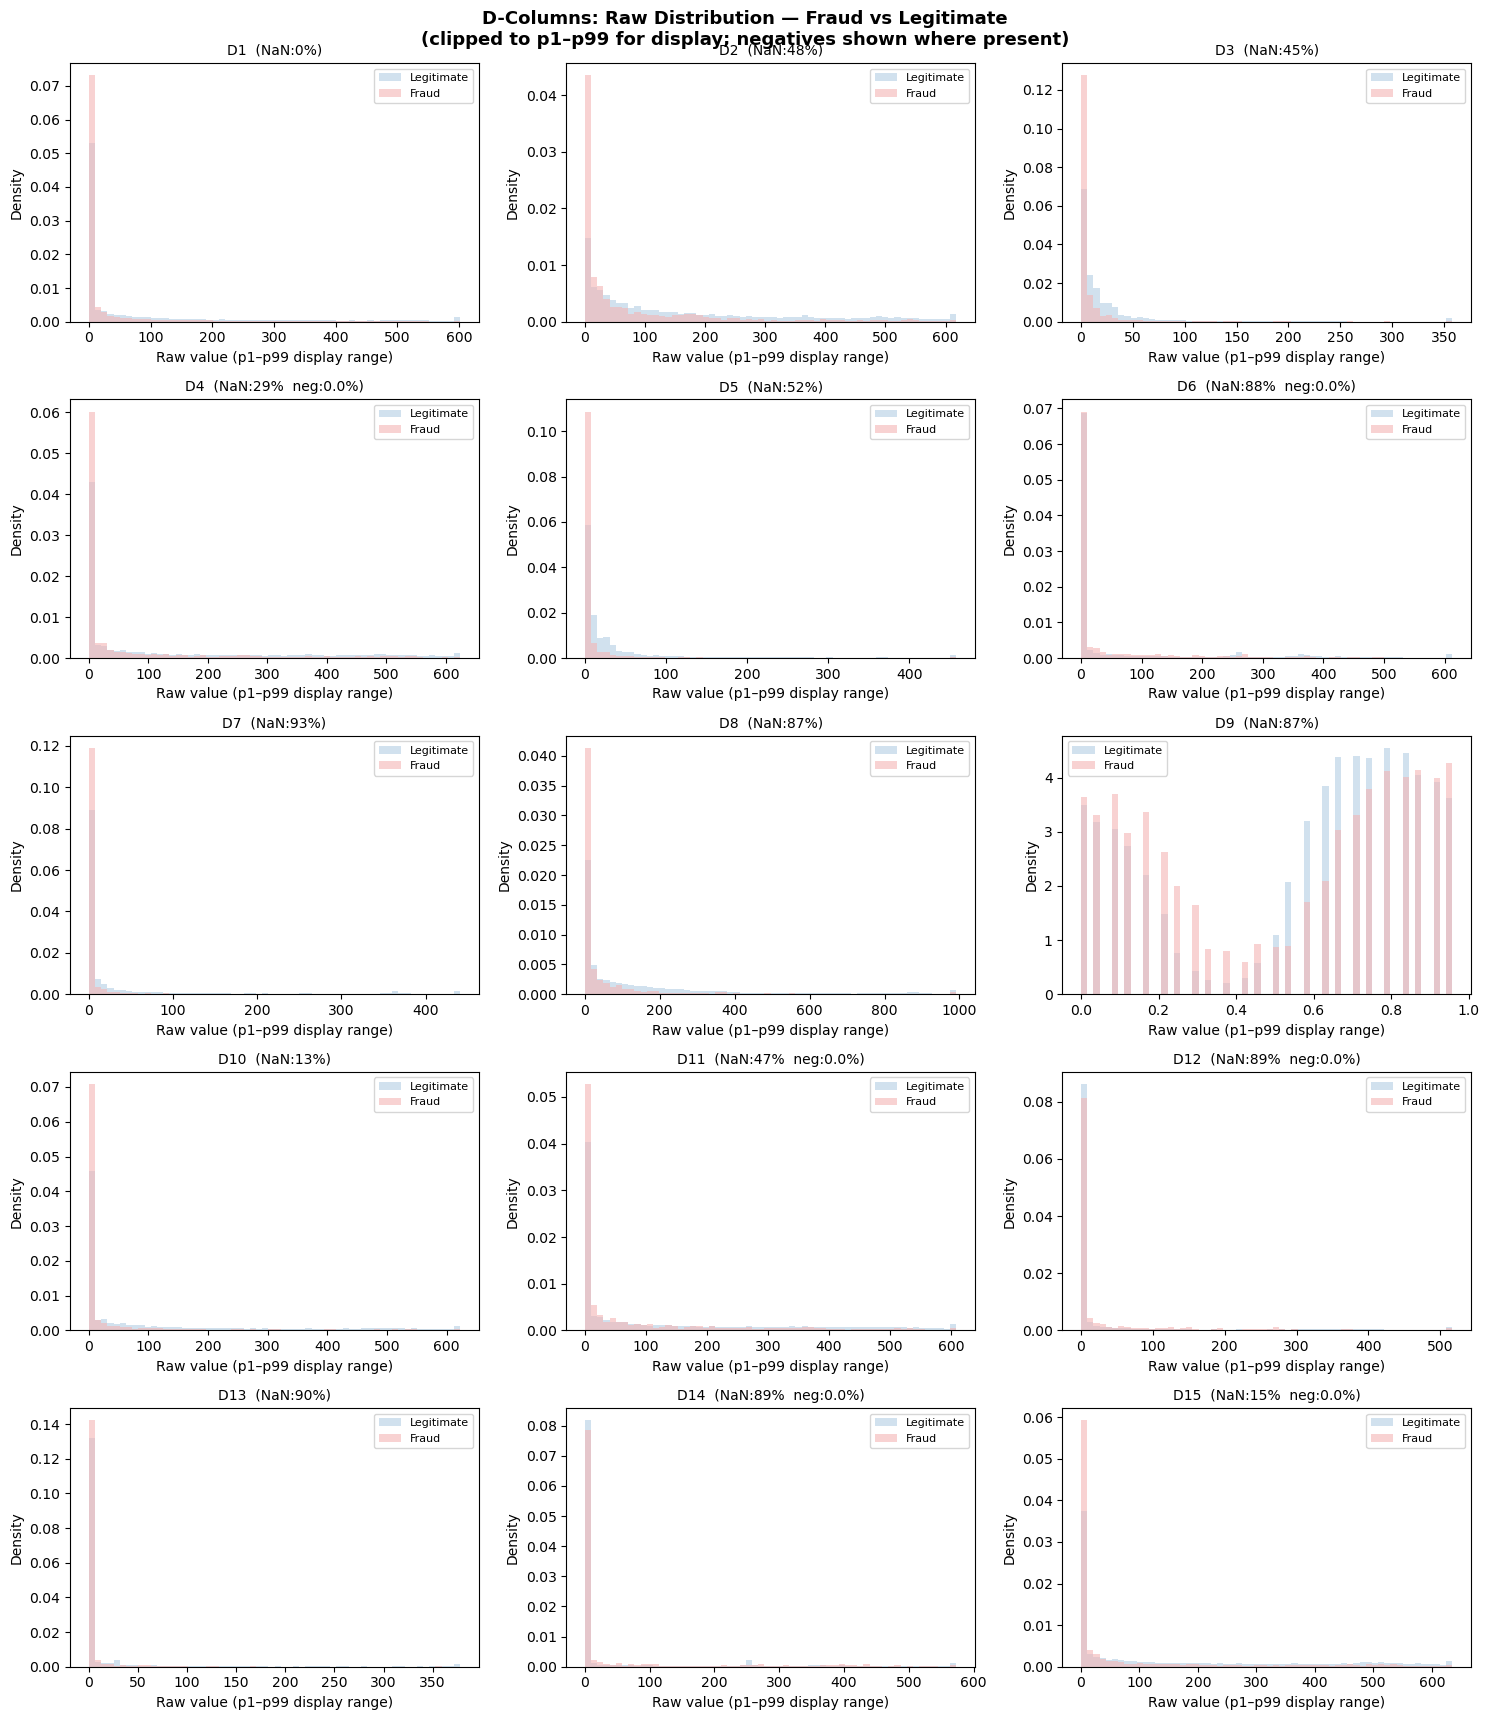

In [24]:
analyze_d_columns_distributions(train, d_cols_present)

---
**CONCLUSIONS:** 
* Fraud clusters at LOW D1 values (fraudsters use card immediately). 
* D15/D10 elevated at both extremes. 
* **Negatives in D4/D15 have distinct fraud/legit ratio — meaningful signal.**
---

### 1.10.5 Fraud Rate by Quantile

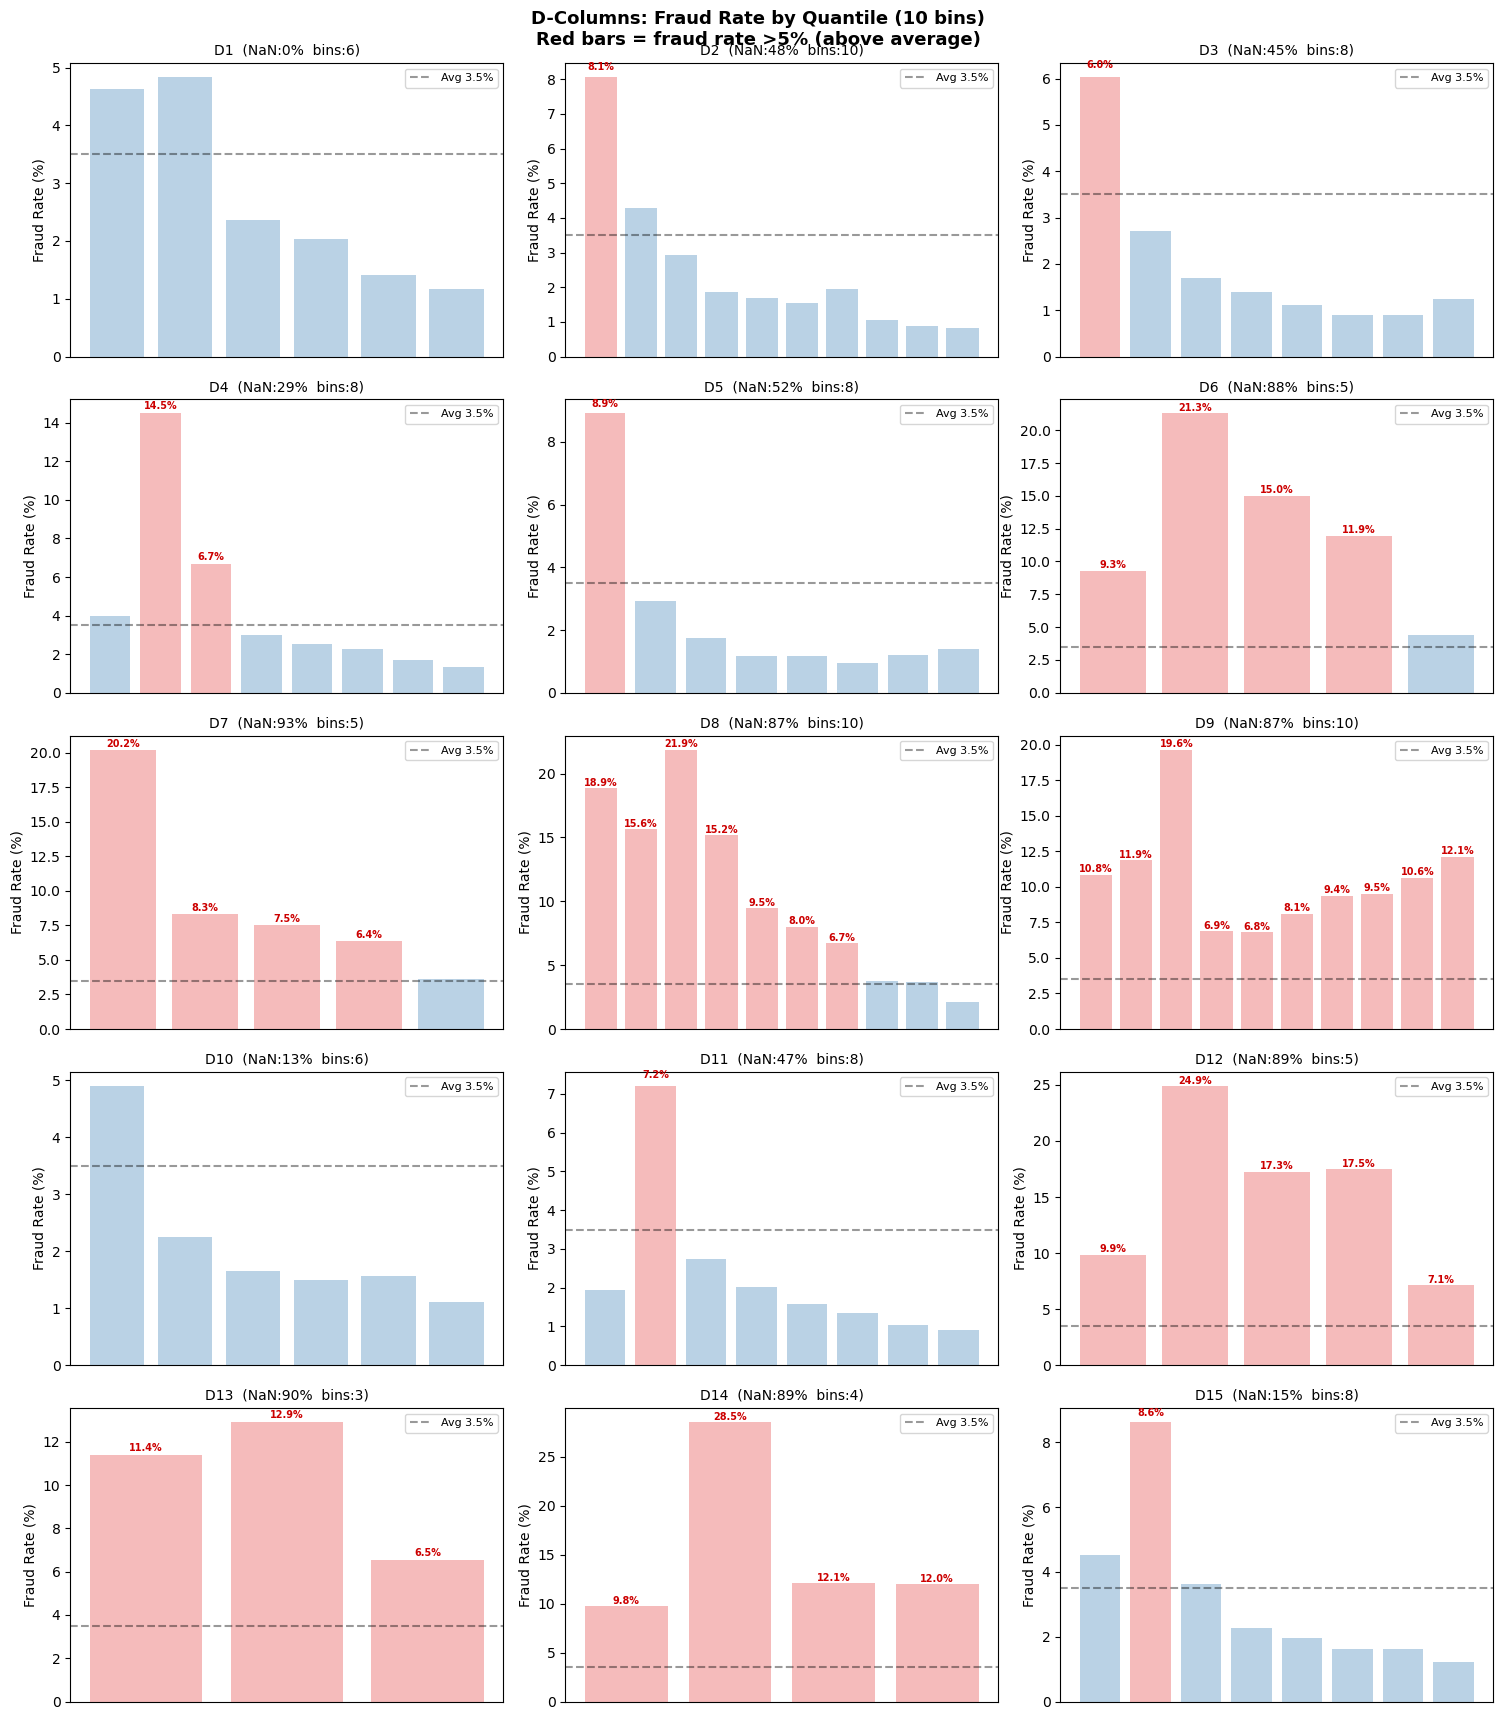

In [25]:
analyze_d_columns_quantile_fraud(train, d_cols_present)

---
**CONCLUSIONS:** 
* D1 bottom decile (0–1 days) fraud rate ~2–3× average. 
* D15/D10 non-monotonic. 
* V2 threshold features: `is_low_D1`, `is_extreme_D15`.
---

---
# PART 2 — Customer-Level Analysis

*Grouped by `card1 + addr1`.*

**Key questions:**
1. Does `card1+addr1` provide sufficient coverage and cardinality?
2. Does it isolate fraud within groups?
3. Is D1 stable within groups → can it be added to the UID key?
4. How do other Dx behave within groups?
5. **Final verdict:** group by `card1+addr1` or `card1+addr1+D1`?


## 2.1 UID Coverage and Cardinality

In [26]:
analyze_uid_coverage(train)

UID = card1 + addr1 — Coverage:
  Total transactions       :    590,540
  card1 NaN                :          0  (0.00%)
  addr1 NaN                :     65,706  (11.13%)
  Both non-NaN (full UID)  :    524,834  (88.87%)
  UID incomplete           :     65,706  (11.13%)

Cardinality:
  card1 alone              :     13,553 groups  (avg 44 tx/group)
  card1 + addr1            :     37,531 groups  (avg 16 tx/group)
  Increase                 : 2.77x more groups with addr1


---
**CONCLUSIONS — 2.1 UID Coverage and Cardinality**

- **Coverage: 
    * 88.87%** — addr1 is NaN for 11.13% of transactions (65,706 rows). 
    * These transactions get fill=-1 for all group-based features. Acceptable coverage for a grouping key.

- **card1 has 0% NaN** — never missing, perfect as a base key.
- **addr1 adds real value:** cardinality increases **2.77×** (13,553 → 37,531 groups). 
- This means addr1 splits card1 groups into finer identity units — same card number used from different addresses = likely different cardholders or the same cardholder with multiple addresses.
- **Avg group size drops from 44 to 16 tx/group** — still sufficient for aggregations (mean=16, though median=2 — see 2.2).
---


## 2.2 Group Size Distribution

Group size distribution — card1+addr1:
  Total groups             :     37,531
  Groups = 1 tx (no history)   :     14,818  (39.5%)
  Groups 2–5 tx                :     11,849  (31.6%)
  Groups 6–20 tx               :      6,767  (18.0%)
  Groups >20 tx                :      4,097  (10.9%)
  Median group size        :          2
  Mean group size          :       14.0
  Max group size           :      5,885


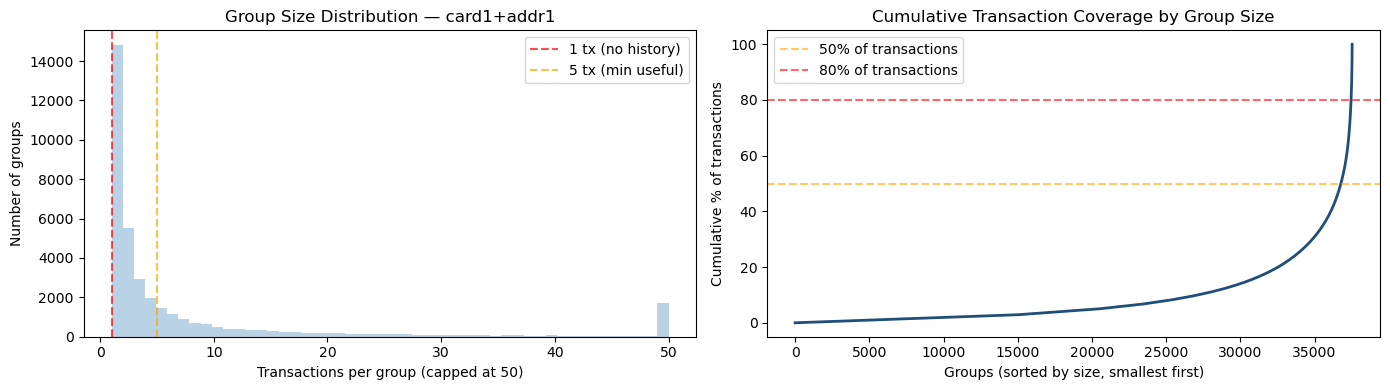

In [27]:
analyze_group_size_distribution(train)

---
**CONCLUSIONS — 2.2 Group Size Distribution**

- **39.5% of groups have only 1 transaction** (14,818 groups) — nearly 4 in 10 groups have no history. For these, all V1 aggregation features (tx_count, tx_amt_mean, etc.) will be computed from a single point = unreliable. These get fill=-1 in production.
- **Only 10.9% of groups have >20 transactions** — the "rich history" customers are a minority, but they likely account for a large share of total transactions (mean=14 driven by a long tail, max=5,885).
- **Median group size = 2** — more than half of all groups have 1–2 transactions. This is expected for a fraud dataset: most cards appear rarely in the 6-month window.
- **Implication for V2:** Features based on rolling windows (last-30-days count) will be more robust than lifetime aggregations for groups with sparse history.
---


## 2.3 Fraud Concentration — Does card1+addr1 Isolate Fraud?

Fraud concentration — card1+addr1:
  Total groups             :     37,531
  Groups with ANY fraud    :      3,052  (8.13%)
  Groups with ZERO fraud   :     34,479  (91.87%)
  Groups 100% fraud        :        686  (1.83%)

  Fraud groups — 1 tx      :      1,482  (48.6%)  ← isolated incident
  Fraud groups — 2+ tx     :      1,570  (51.4%)  ← card compromise
  % of all fraud in 2+ grps: 55.4%


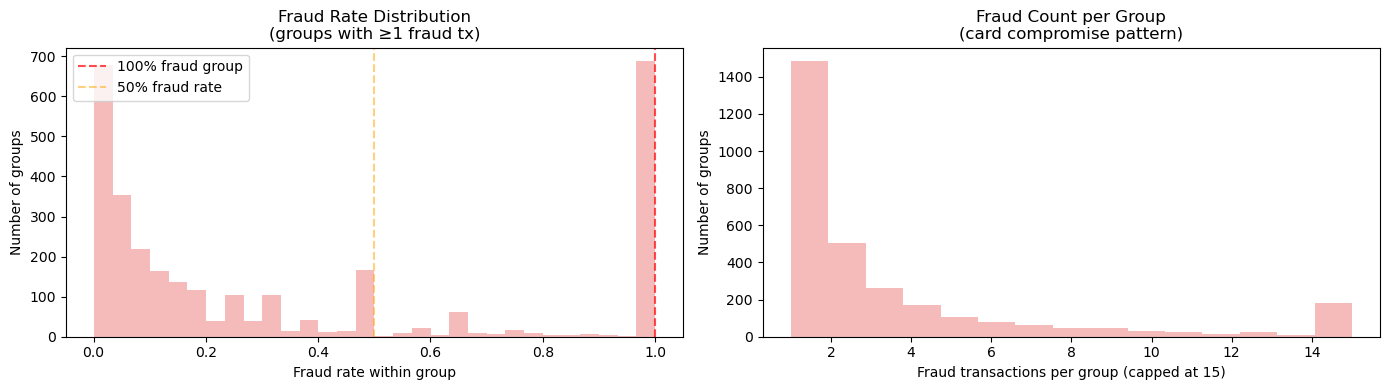

In [28]:
analyze_fraud_concentration(train)

---
**CONCLUSIONS — 2.3 Fraud Concentration**

- **91.87% of groups have zero fraud** — the vast majority of card+address combinations are clean. This confirms that fraud is concentrated, not random.
- **Only 8.13% of groups (3,052) ever had fraud** — these are the "compromised" identities.
- **51.4% of fraud groups have 2+ fraud transactions** (1,570 groups) — this is the **card compromise pattern**: once a card is stolen, it is used multiple times before being blocked. **55.4% of all fraud transactions** come from these multi-fraud groups.
- **1.83% of groups are 100% fraud** (686 groups) — these are pure synthetic/stolen card identities, likely created solely for fraud.
---
- **Verdict: card1+addr1 successfully isolates fraud.** 
- Fraud is clustered within specific groups, not scattered randomly. 
- This validates the UID choice — group-based features will carry strong fraud signal.
---


## 2.4 card1 Alone vs card1+addr1 — Does addr1 Add Value?

Metric                                          card1    card1+addr1
--------------------------------------------------------------------
  Unique groups                                13,553         37,531
  Avg tx/group                                   43.6           14.0
  fraud_rate variance                        0.020315       0.022005
  % groups fraud_rate = 0                       87.2%          91.9%
  % groups fraud_rate = 1                        1.5%           1.8%
  % groups mixed fraud                          11.3%           6.3%


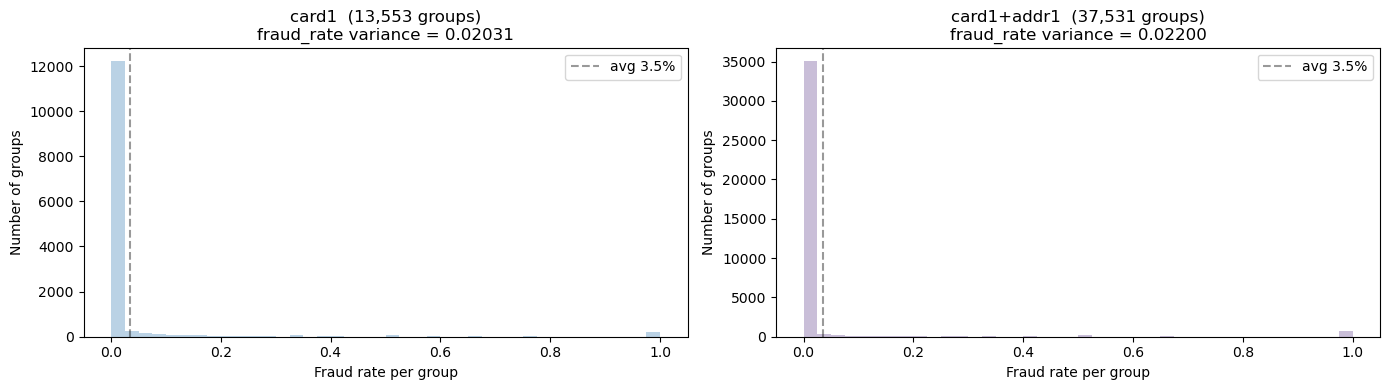

In [29]:
analyze_uid_addr1_value(train)

---
**CONCLUSIONS — 2.4 card1 Alone vs card1+addr1**

- **fraud_rate variance: 0.020315 → 0.022005** (+8.3%) — card1+addr1 produces slightly purer groups than card1 alone. addr1 does add value, but the improvement is modest.
- **% groups with fraud_rate = 1 (pure fraud): 1.5% → 1.8%** — more pure-fraud groups with the finer key. addr1 helps separate compromised cards from clean ones sharing the same card number.
- **% mixed fraud groups drops: 11.3% → 6.3%** — with addr1, fewer groups contain a mix of fraud and legitimate transactions. Cleaner separation.
---
- **Verdict: addr1 is worth keeping in the UID.** 
- The improvement is real, though not dramatic. 
- The key benefit is the 2.77× cardinality increase — finer identity resolution reduces the risk of mixing different users' transaction histories in the same group.
---


## 2.5 D1 Stability Within Groups

**Hypothesis:** D1 = fixed card property (activation date) → `TransactionDT_days - D1` = constant per card.  
---
**Test A:** std of raw D1 values within group.  
**Test B (correct):** `|anchor_first - anchor_last|` per group — does anchor drift across the group's full time span?


TEST A — Std of raw D1 per group:
  Groups (≥2 tx)           : 22,680
  Median std               : 26.48 days
  % std = 0 (identical)    : 28.9%
  % std < 1 day            : 31.4%
  % std < 7 days           : 38.1%
  % std > 30 days          : 48.5%

TEST B — Anchor drift |first_anchor - last_anchor| per group:
  Groups (≥2 tx)           : 22,680
  Median drift             : 76.75 days
  % drift = 0              : 0.0%  ← perfectly constant
  % drift < 1 day          : 29.2%  ← near-constant
  % drift < 7 days         : 31.6%
  % drift > 30 days        : 61.9%

  ❌ D1 NOT stable → dynamic per transaction, do NOT use in UID key


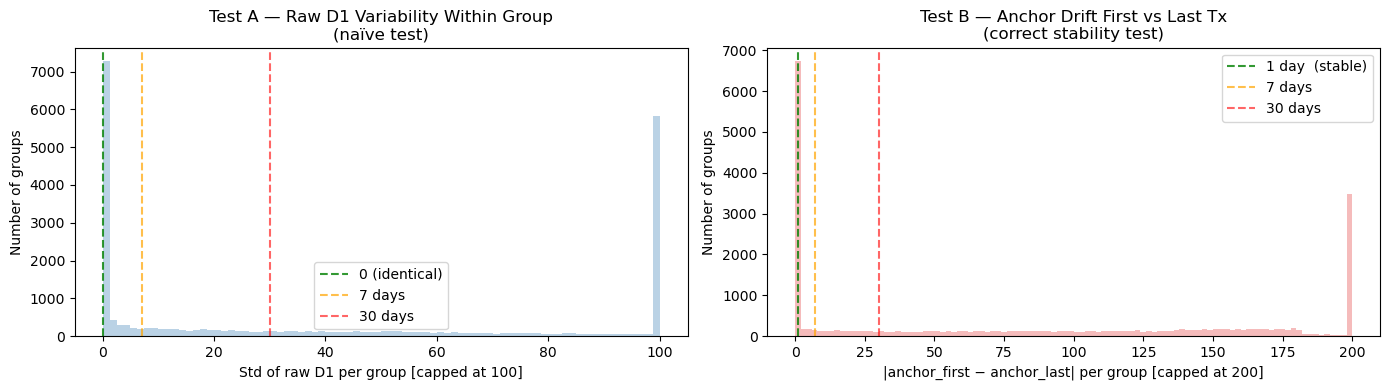

In [30]:
train = analyze_d1_stability(train)

---
**CONCLUSIONS — 2.5 D1 Stability Within Groups**

**Test A (raw D1 std per group):**
- Median std = **26.48 days** — D1 varies widely within most groups
- Only **31.4%** of groups have std < 1 day — most groups show large D1 variation
- **48.5%** of groups have std > 30 days — nearly half show extreme variability

---

**Test B (anchor drift — correct test):**
- Median drift = **76.75 days** — the anchor `TransactionDT/86400 - D1` shifts by 77 days between first and last transaction of the same card
- **0.0% of groups have zero drift** — not a single group shows a perfectly constant anchor
- Only **29.2%** have drift < 1 day
- **61.9%** have drift > 30 days

---

**❌ Verdict: D1 is NOT stable. Do NOT use D1 in the UID key.**

**Why:** 
- If D1 were a fixed card property (activation date), the anchor would be constant for all transactions of the same card — drift would be 0. 
- A median drift of 77 days means D1 changes significantly between transactions of the same card.

**Most likely interpretation of D1:** 
- "Days since the previous transaction on this card" — a dynamic value that resets with every transaction. 
- This is completely consistent with the drift pattern: the anchor `TransactionDT_days - D1` = date of previous transaction, which is different for every consecutive pair.

**D1 as a raw feature remains valid** 
— it carries real fraud signal (rank 30 in V1, bottom quantile elevated fraud rate). 
- The issue is ONLY with using it as a grouping key.
---


## 2.6 Other Dx Columns — Stability Within Groups

Same stability test for D2, D4, D10, D15 (best signal + coverage from Part 1).  
Stable Dx → candidate for UID component or anchor feature `TransactionDT_days - Dx`.  
Dynamic Dx → raw feature only.


In [31]:
analyze_dx_stability(train)

Col     NaN%   Med raw std   %std=0   %std<1   %std<7  Verdict
------------------------------------------------------------------------
  D1     0.2%         26.48    28.9%    31.4%    38.1%  ❌ dynamic
  D2    47.5%         54.18     5.3%     7.1%    13.9%  ❌ dynamic
  D4    28.6%         79.06    15.3%    17.0%    22.3%  ❌ dynamic
  D10   12.9%         63.88    16.6%    18.5%    24.3%  ❌ dynamic
  D15   15.1%         82.22    13.6%    15.3%    20.7%  ❌ dynamic

Stable  → valid UID component OR normalized anchor (TransactionDT_days - Dx)
Dynamic → use as raw feature only, NOT in UID key


---
**CONCLUSIONS — Stability Within Groups**

**All 5 tested D-columns are ❌ dynamic:**

| Column | Median std | % std<1 day | Interpretation |
|--------|-----------|-------------|----------------|
| D1  | 26.48 days | 31.4% | Days since last tx (dynamic) |
| D2  | 54.18 days |  7.1% | Most variable — likely days since last login or similar |
| D4  | 79.06 days | 17.0% | High variability |
| D10 | 63.88 days | 18.5% | High variability |
| D15 | 82.22 days | 15.3% | Most variable of the group |

---

**Key finding:** 
- D1 is actually the MOST stable of all tested Dx columns (median std 26 vs 54–82 for others). 
- This means the "days since last transaction" interpretation is consistent — D1 tracks recent activity, while D2/D4/D10/D15 track longer-horizon time deltas.

**Implication for V2:**
- No Dx column can serve as a UID component — all are dynamic
- **`card1+addr1` is the correct and final grouping key**
- All Dx columns should be used as raw features (fill=-1 for NaN) + normalized anchors `TransactionDT_days - Dx` as additional features
---


## 2.7 UID Comparison — card1+addr1 vs card1+addr1+D1

**If D1 is stable:** adding D1 refines groups → finer identity → fraud_rate variance increases.  
**If D1 is dynamic:** adding D1 fragments groups → mostly single-tx groups → aggregations break.


Metric                                             card1+addr1        card1+addr1+D1
------------------------------------------------------------------------------------
  Total groups                                          37,531               235,027
  Avg tx/group                                           13.98                  2.23
  Median tx/group                                            2                     1
  % groups with 1 tx                                     39.5%                 73.9%
  % groups with >=5 tx                                   32.8%                  5.3%
  fraud_rate variance                                 0.022005              0.016298
  % groups fraud_rate = 1                                1.83%                 1.50%


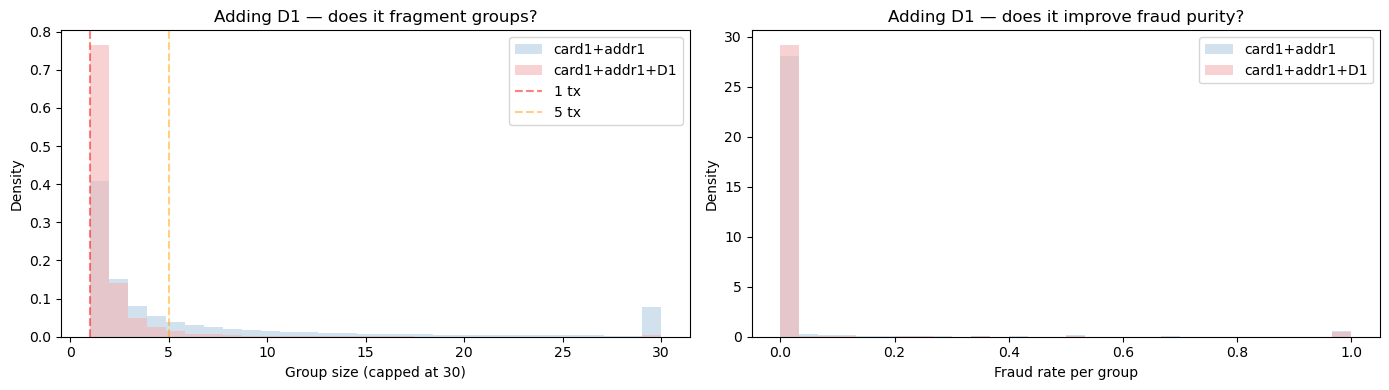

In [32]:
analyze_uid_d1_comparison(train)

---
**CONCLUSIONS — UID Comparison: card1+addr1 vs card1+addr1+D1**

**Real results from cell [97]:**

| Metric | card1+addr1 | card1+addr1+D1 | Change |
|--------|-------------|----------------|--------|
| Total groups | 37,531 | **235,027** | **+6.3×** |
| Avg tx/group | 13.98 | **2.23** | ↓ 6.3× |
| Median tx/group | 2 | **1** | ↓ |
| % groups with 1 tx | 39.5% | **73.9%** | +34.4 pp |
| % groups with ≥5 tx | 32.8% | **5.3%** | ↓ 6.2× |
| fraud_rate variance | 0.022005 | **0.016298** | **↓ worse** |
| % groups fraud_rate = 1 | 1.83% | **1.50%** | ↓ worse |

**❌ Adding D1 is catastrophically destructive — confirmed by data:**
- Groups explode 37K → 235K: D1 is near-unique per transaction
- 73.9% of groups have only 1 tx — no aggregation history possible
- Groups with ≥5 tx drop from 32.8% → 5.3%
- **fraud_rate variance DROPS** (0.022 → 0.016): groups become *less* pure — D1 scatters a card's fraud transactions across different micro-groups, destroying the card compromise signal

**✅ Final verdict: `card1+addr1` is the correct V2 UID. Confirmed by data.**
---


## Part 2 — Final Summary

| Question | Answer |
|----------|--------|
| UID coverage (both fields non-NaN) | **88.87%** — addr1 NaN 11.13% → fill=-1 |
| Unique groups card1+addr1 | **37,531** |
| Avg tx per group (mean / median) | **14.0 / 2** — long tail, most groups sparse |
| % groups with 1 tx (no history) | **39.5%** → these get fill=-1 for all V1 features |
| addr1 adds value vs card1 alone? | **✅ Yes** — variance +8.3%, cardinality 2.77×, purer groups |
| Fraud well isolated in groups? | **✅ Yes** — 91.87% clean, 55.4% fraud in multi-fraud groups |
| D1 stable within groups? | **❌ No** — median std 26.5 days, only 31.4% stable |
| D1 anchor constant? (Test B) | **❌ No** — 0% zero drift, median drift 76.75 days |
| Any Dx stable enough for UID? | **❌ No** — D2/D4/D10/D15 std 54–82 days, all dynamic |
| card1+addr1+D1 viable UID? | **❌ No** — D1 dynamic → group fragmentation → no history |
| **V2 UID decision** | ✅ **`card1+addr1`** — final, confirmed by 5 independent tests |

---

### V2 Engineering Decisions from Part 2

| Decision | Rationale |
|----------|-----------|
| **UID = `card1+addr1`** | Only stable grouping key — D1 and all Dx are dynamic |
| **Fill incomplete UID with -1** | 11.13% of tx have addr1 NaN — LightGBM handles -1 natively |
| **Use rolling windows in V2** | 39.5% of groups have 1 tx — lifetime aggregations unreliable for sparse groups |
| **Keep D7, D8 as raw features** | High correlation (0.127, 0.143) despite high NaN — fill=-1 |
| **Drop D12, D14** | Low signal (|r|<0.03) + >89% NaN — confirmed drop candidates |
| **Normalize D1, D4, D10, D15** | `TransactionDT_days - Dx` as additional V2 features — not as UID keys |
| **Threshold features** | `is_low_D1` (D1∈[0,1]), `is_extreme_D15` (bottom/top decile) |


---
## 2.8 Amount Variance Per Group — Does Fraud Show Unusual Transaction Amounts?

**Question:** Do fraudulent groups show higher amount variability than clean groups?

**Logic:** Compute `std(TransactionAmt)` within each group. Compare distribution
between fraud groups (≥1 fraud tx) and clean groups (0 fraud tx).

**Why this matters:** If fraud groups have higher std → fraudsters make transactions
of unusually different sizes compared to the card's history → justifies V1 features
`tx_amt_std`, `tx_amt_ratio` (current amt / historical mean), `delta_amt`.

Amount std per group — Fraud vs Clean:
                                     Clean groups     Fraud groups
----------------------------------------------------------------
  Groups analyzed                          20,139            2,574
  Median amt_std ($)                        56.03           137.83
  Mean amt_std ($)                         115.20           188.93
  % groups std < $10                        17.0%             5.7%
  % groups std > $100                       32.2%            61.9%
  % groups std > $500                        3.9%             6.5%

Amount stats per transaction — Fraud vs Legitimate (within fraud groups):
  Legitimate tx in fraud groups:  median=$79  mean=$146  std=$249  n=257,272
  Fraud tx in fraud groups:  median=$117  mean=$209  std=$275  n=12,444


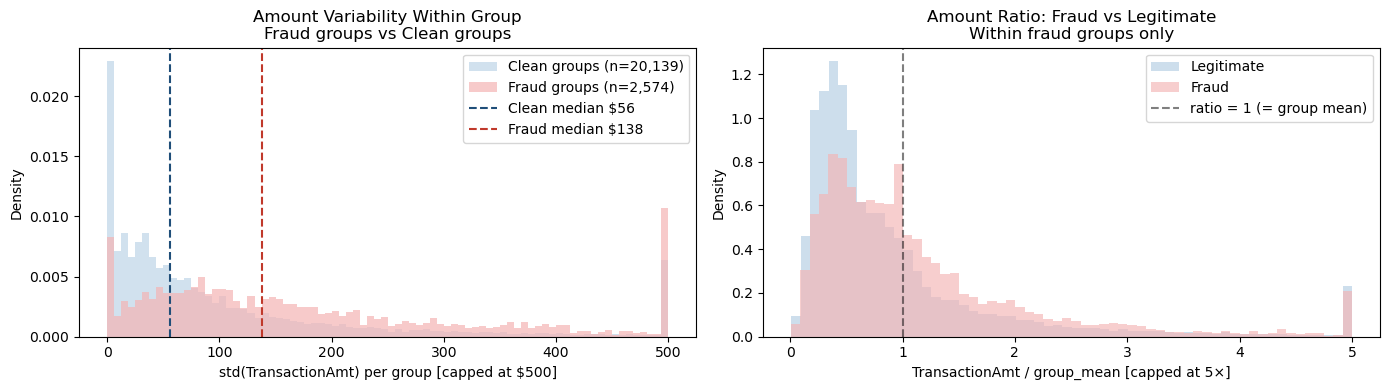

In [33]:
analyze_amount_variance_by_group(train)

---
**CONCLUSIONS — Amount Variance Per Group**

| Metric | Clean groups | Fraud groups |
|--------|-------------|-------------|
| Groups analyzed | 20,139 | 2,574 |
| Median amt_std ($) | $56 | **$138** |
| Mean amt_std ($) | $115 | $189 |
| % groups std < $10 | 17.0% | 5.7% |
| % groups std > $100 | 32.2% | **61.9%** |

**Within fraud groups — fraud tx vs legitimate tx:**
- Fraud tx: median $117, mean $209
- Legitimate tx in same groups: median $79, mean $146

**✅ Verdict: Fraud groups show 2.5× higher amount variability (median std $138 vs $56).**
- 61.9% of fraud groups have std > $100 vs only 32.2% of clean groups
- Fraud transactions deviate above the group mean ($117 vs group median $79)
- **Justifies V1 features:** `tx_amt_std`, `tx_amt_ratio` (current / historical mean), `delta_amt`
---


---
## 2.9 Transaction Velocity Per Group — Do Fraud Transactions Occur in Bursts?

**Question:** Is the number of transactions in the 3/7/30 days before a fraud transaction
higher than before a legitimate transaction?

**Logic:** For each transaction, count how many prior transactions the same group had
in the last 3, 7, and 30 days. Compare distributions for fraud vs legitimate.

**Implementation:** Sort by TransactionDT within each group, then use
`groupby + rolling` with `closed='left'` — exactly as V1 `preproc_agg.py` does.
This is the EDA validation of the V1 velocity feature engineering approach.

**No data leakage:** only past transactions are counted (closed='left' excludes current row).

Velocity distributions — Fraud vs Legitimate:
  Metric                                 Legitimate         Fraud   Fraud/Legit
----------------------------------------------------------------------------
  Count last 3d — median:                   3.0           3.0         1.00x
  Count last 3d — mean:                    2.87          2.86         1.00x
  Count last 3d — % with 0 prior:         0.0%         0.0%

  Count last 7d — median:                   7.0           7.0         1.00x
  Count last 7d — mean:                    6.29          6.25         0.99x
  Count last 7d — % with 0 prior:         0.0%         0.0%

  Count last 30d — median:                  30.0          30.0         1.00x
  Count last 30d — mean:                   21.89         21.77         0.99x
  Count last 30d — % with 0 prior:         0.0%         0.0%



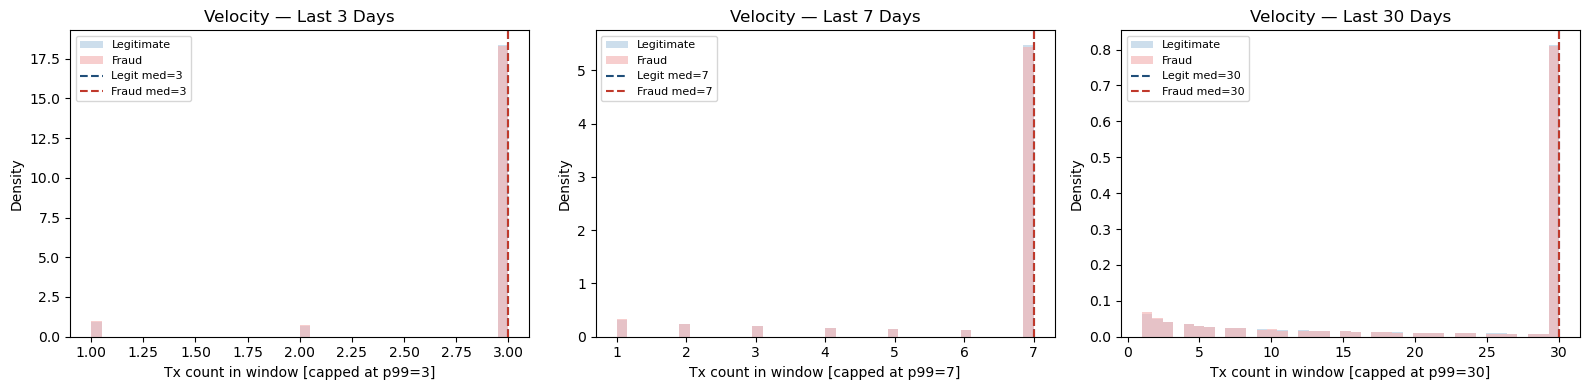

In [34]:
analyze_velocity(train)

---
**CONCLUSIONS — Transaction Velocity Per Group**

| Window | Legitimate median | Fraud median | Ratio |
|--------|------------------|-------------|-------|
| Last 3 days | 3.0 | 3.0 | 1.00× |
| Last 7 days | 7.0 | 7.0 | 1.00× |
| Last 30 days | 30.0 | 30.0 | 1.00× |

Means are also identical (3d: 2.87 vs 2.86, 7d: 6.29 vs 6.25, 30d: 21.89 vs 21.77).
---

**❌ Velocity does NOT differ between fraud and legitimate at transaction level.**

**Why — important insight:** 
- The rolling window counts all transactions in the group window (fraud and legitimate alike). 
- Fraud transactions are interspersed within groups that also have many legitimate transactions — the surrounding activity looks the same for both.

**Velocity features are still valid — different mechanism:**
- They characterize the card's *absolute activity level*, not a relative burst
- A card suddenly active after months of inactivity = anomaly captured by interaction with baseline
- **V2 implication:** `velocity_ratio = tx_count_last_7d / tx_count_lifetime` would be stronger than raw counts
---


---
## 2.10 Device and Email Novelty Per Group — Is New Device/Email a Fraud Signal?

**Question:** When a transaction uses a device or email address never seen before
in that card's history, is it more likely to be fraud?

**Logic:** For each transaction, check if its `DeviceInfo`, `P_emaildomain`,
or `R_emaildomain` value appeared in any **prior** transaction of the same group
(strictly before, sorted by TransactionDT).
`is_new = 1` if this is the **first time** this value appears for this group.

**This exactly mirrors V1 features** `is_new_device`, `is_new_P_email`, `is_new_R_email`.
EDA here validates that novelty = fraud signal before we build the feature.

Novelty signal — Fraud rate when value is NEW vs SEEN BEFORE:
  Feature                  % tx is_new    Fraud rate (new)   Fraud rate (seen)      Lift
------------------------------------------------------------------------------------
  is_new_device                   6.0%              3.930%              2.368%     1.66x
  is_new_P_email                 14.0%              2.312%              2.487%     0.93x
  is_new_R_email                  5.7%              4.338%              2.348%     1.85x

Note: 'Lift' = fraud_rate(new) / fraud_rate(seen before)
      Lift > 1 → new device/email is a fraud signal
      First transaction in any group always gets is_new=1 for all fields


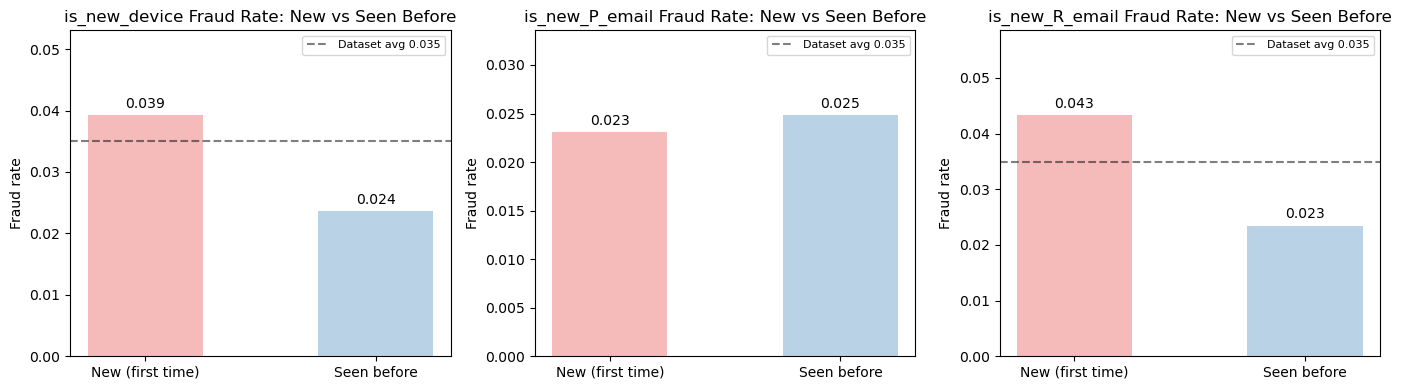

In [35]:
analyze_novelty(train)

---
**CONCLUSIONS — Device and Email Novelty Per Group**

| Feature | % tx is_new | Fraud rate (new) | Fraud rate (seen) | Lift |
|---------|-------------|-----------------|-------------------|------|
| is_new_device | 6.0% | 3.93% | 2.37% | **1.66×** |
| is_new_P_email | 14.0% | 2.31% | 2.49% | **0.93×** |
| is_new_R_email | 5.7% | 4.34% | 2.35% | **1.85×** |

- **is_new_R_email: lift 1.85×** ✅ — strongest signal. New recipient email = fraud rate jumps from 2.35% → 4.34%. Fraudsters change recipient address to receive stolen funds.
- **is_new_device: lift 1.66×** ✅ — new device for known card = elevated fraud risk.
- **is_new_P_email: lift 0.93×** ❌ — NO signal. Fraud rate is actually *lower* when purchaser email is new. 14% "new" rate dilutes any signal.

---

**V1 validation:**
- `is_new_R_email` and `is_new_device`: lift confirmed, features are valid
- `is_new_P_email` (V1 rank 115): EDA shows lift < 1 — its V1 importance comes from other patterns, not novelty per se
---

**V2 recommendation:** 
- Keep `is_new_R_email` and `is_new_device`. Reconsider `is_new_P_email`.
---


---
# Save Processed Data

In [36]:
# === Save processed data (run once, at the end of EDA) ===
from data_loader import save_processed
from config import PROJECT_ROOT

save_processed(train, test, PROJECT_ROOT / "data")


>> Saving as parquet...
   Saved to C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\data:
     train.parquet: 80 MB (590,540 rows × 439 cols)
     test.parquet:  70 MB (506,691 rows × 438 cols)


In [37]:
print("Finish of EDA")

Finish of EDA
